## 4. Modelaje

### 4.1 Regresión logística

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import pickle

# Cargar los datos guardados en la Fase 3
with open('../data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']
feature_names = data['feature_names']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Targets en train:", y_train.sum())
print("Targets en test:", y_test.sum())

X_train: (3458, 26)
X_test: (1482, 26)
Targets en train: 1086
Targets en test: 466


##### Creamos el modelo

In [3]:
# Convertir a DataFrame con nombres de features
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)

X_train_c = sm.add_constant(X_train_df, prepend=True)

# Regresión logística con statsmodels
model_logit = sm.Logit(endog=y_train, exog=X_train_c.astype(float))
model_logit = model_logit.fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.605388
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 3458
Model:                          Logit   Df Residuals:                     3431
Method:                           MLE   Df Model:                           26
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                 0.02719
Time:                        16:54:06   Log-Likelihood:                -2093.4
converged:                       True   LL-Null:                       -2151.9
Covariance Type:            nonrobust   LLR p-value:                 1.642e-13
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.8294      0.039    -21.307      0.000      -0.906      -0.753
exchg         

Variables significativas (p < 0.05):
- cash_ratio (0.233, p=0.000) → mayor liquidez = más probable ser target, tiene sentido financiero
- exchg (-0.161, p=0.000) → la bolsa donde cotiza influye
- sich (-0.122, p=0.002) → el sector industrial influye
- ev_ebitda (0.086, p=0.022) → mayor valoración = más probable ser target
- leverage (-0.123, p=0.009) → menos deuda = más probable ser target
- capex_intensity (-0.137, p=0.032) → menos inversión en capex = más probable
- asset_turnover (-0.107, p=0.016) → interesante, menos eficiencia operativa = más probable
- ap (0.936, p=0.036) → más cuentas a pagar = más probable

Variables no significativas (p > 0.05): at, che, lt, rect, wcap, dp, ebitda, ni, sale, xsga, capx, csho, prcc_f, total_debt, ebitda_margin, roa, current_ratio, market_cap

Conclusión: el Pseudo R² de 0.027 es muy bajo luego la regresión logística sola no captura bien la señal. Esto confirma lo que dijimos antes: necesitamos modelos no lineales como Random Forest o Gradient Boosting.

##### Predicción y accuracy en el train

In [4]:
# Predicción en train
predict_train = model_logit.predict(exog=X_train_c.astype(float))
clas_train = np.where(predict_train < 0.5, 0, 1)

accuracy_train = accuracy_score(y_true=y_train, y_pred=clas_train, normalize=True)
print(f"Accuracy en train: {100*accuracy_train:.2f}%")

Accuracy en train: 68.42%


##### Confusion matrix en train

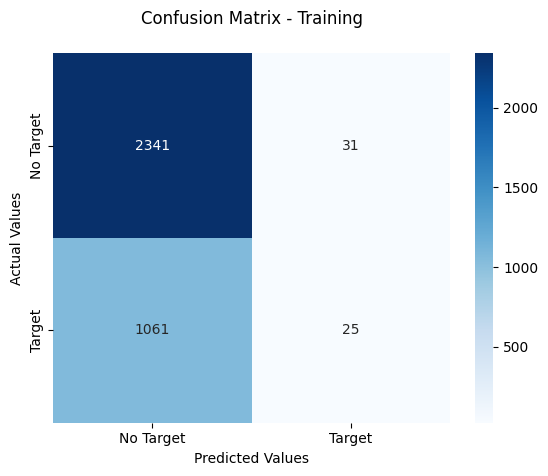

In [5]:
confusion = pd.crosstab(
    y_train.ravel(),
    clas_train,
    rownames=['Real'],
    colnames=['Predicción']
)

ax = sns.heatmap(confusion, annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Training\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

##### Evaluación en test

Accuracy en test: 68.29%
AUC-ROC: 0.5602


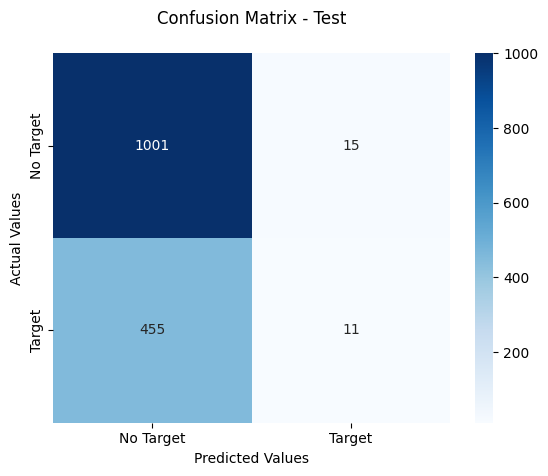

In [6]:
# Predicción en test
X_test_c = sm.add_constant(X_test, prepend=True, has_constant='add')
predict_test = model_logit.predict(exog=X_test_c.astype(float))
clas_test = np.where(predict_test < 0.5, 0, 1)

accuracy_test = accuracy_score(y_true=y_test, y_pred=clas_test, normalize=True)
print(f"Accuracy en test: {100*accuracy_test:.2f}%")

# AUC-ROC
auc = roc_auc_score(y_test, predict_test)
print(f"AUC-ROC: {auc:.4f}")

# Confusion Matrix test
confusion_test = pd.crosstab(
    y_test.ravel(),
    clas_test,
    rownames=['Real'],
    colnames=['Predicción']
)
ax = sns.heatmap(confusion_test, annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Test\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

La regresión logística establece el baseline del proyecto con resultados modestos. El accuracy del 68% en test es engañoso, un clasificador que predijera siempre "No Target" obtendría el mismo resultado dado el desbalance de clases. El AUC-ROC de 0.56, apenas por encima del 0.5 de un clasificador aleatorio, confirma que el modelo no discrimina de forma útil entre empresas target y no target. La confusion matrix revela el problema central: de 466 targets reales en test, el modelo solo identifica 11 correctamente, clasificando los 455 restantes como no targets. Esto se debe a que la regresión logística, al ser un modelo lineal, no es capaz de capturar las interacciones no lineales entre variables financieras que determinan si una empresa es objetivo de adquisición — algo que ya anticipaba el Pseudo R² de 0.027 y la baja correlación individual de las variables con ma_target observada en el EDA. Estos resultados justifican el uso de modelos más complejos como Random Forest y Gradient Boosting en los siguientes pasos.

### 4.21 Random Forest

##### Creación del modelo

In [7]:
from sklearn.ensemble import RandomForestClassifier

# En clase: max_features = sqrt(n_predictors)
# Tienes 26 features → sqrt(26) ≈ 5
import math
m = round(math.sqrt(X_train.shape[1]))
print(f"Número de features por árbol (m): {m}")

# Creación del modelo
rf = RandomForestClassifier(
        n_estimators = 100,   # número de árboles
        oob_score    = True,
        max_depth    = None,
        max_features = m,
        n_jobs       = -1,
        random_state = 123
     )

rf.fit(X_train, y_train)
print("OOB Score:", rf.oob_score_)

Número de features por árbol (m): 5
OOB Score: 0.714864083285136


##### Evaluación en train y test

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

# Predicciones
pred_train = rf.predict(X_train)
pred_test  = rf.predict(X_test)
prob_test  = rf.predict_proba(X_test)[:, 1]

# Accuracy
print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")

# Confusion Matrix - Train
print("\nConfusion Matrix -- TRAIN")
print(confusion_matrix(y_train, pred_train))

# Confusion Matrix - Test
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 100.00%
Accuracy en test:  71.12%
AUC-ROC:           0.7136

Confusion Matrix -- TRAIN
[[2372    0]
 [   0 1086]]

Confusion Matrix -- TEST
[[920  96]
 [332 134]]


##### Confusion matrix en test

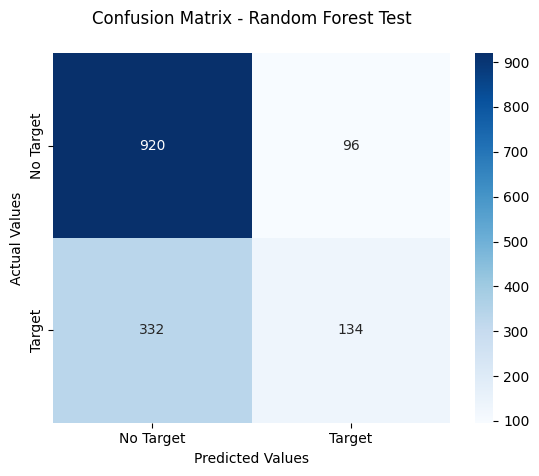

In [9]:
cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Random Forest Test\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

##### Feature importance

          predictor  importance
22       market_cap    0.049890
23        ev_ebitda    0.047914
3               che    0.047724
25       cash_ratio    0.044308
13             csho    0.043235
24   asset_turnover    0.042344
14           prcc_f    0.040784
19  capex_intensity    0.039910
1                ap    0.038971
17    ebitda_margin    0.038874
10             sale    0.038208
8            ebitda    0.037657
11             xsga    0.037040
2                at    0.037005
4                lt    0.036749
7                dp    0.036177
12             capx    0.036152
20              roa    0.036021
18         leverage    0.035667
5              rect    0.035257
15             sich    0.035170
9                ni    0.034758
6              wcap    0.033766
21    current_ratio    0.033450
0             exchg    0.032032
16       total_debt    0.030937


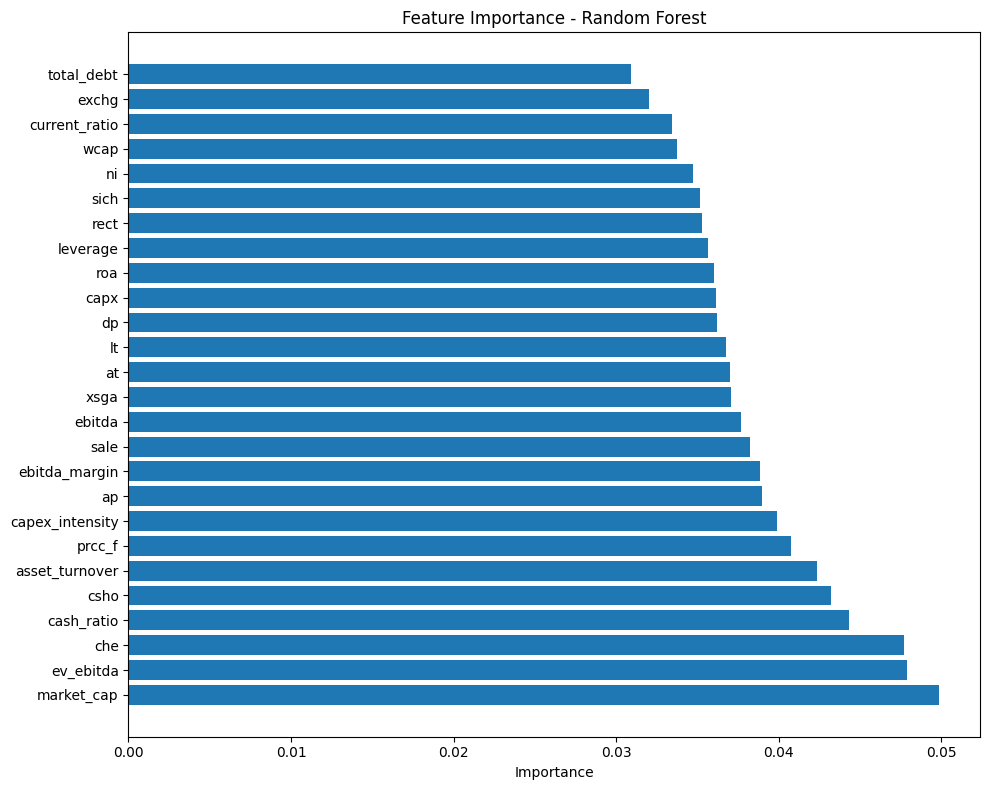

In [10]:
feature_importance = pd.DataFrame({
    'predictor': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance['predictor'], feature_importance['importance'])
ax.set_title('Feature Importance - Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

##### Curva ROC

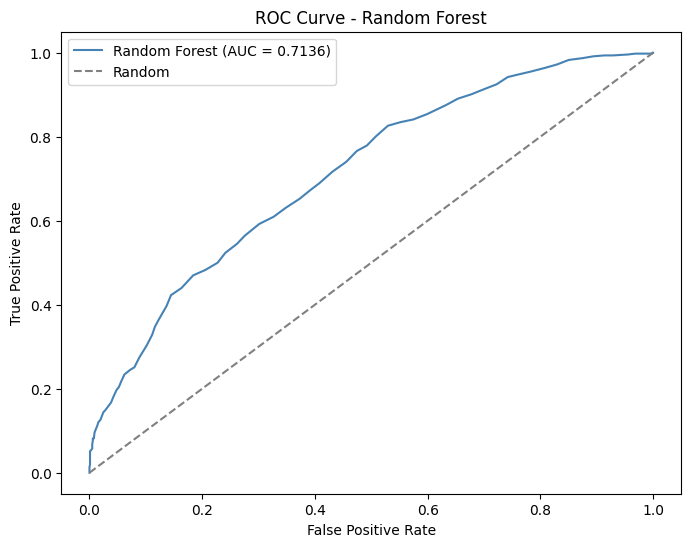

In [11]:
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

##### Conclusiones de primer modelo Random Forest

**Accuracy y AUC-ROC:**
- Accuracy test: 71.12% (vs 68.29% logística) —-> mejora leve
- AUC-ROC: 0.7136 (vs 0.5602 logística) — **mejora enorme**, el modelo ahora discrimina de verdad

**Confusion Matrix test:**
- Identifica 134 targets correctamente (vs 11 de la logística) — **mejora x12** 
- Pero sigue fallando 332 targets — recall del 29% (identifica 1 de cada 3 targets reales)
- 96 falsos positivos — empresas que predice como target pero no lo son

**Overfitting claro:**
- Train: 100% accuracy, identifica todos los targets perfectamente
- Test: 71% accuracy, el modelo ha memorizado el train en vez de generalizar

**Feature Importance:**
Las variables más importantes son market_cap, ev_ebitda, che (cash), cash_ratio y csho, lo cual tiene sentido financiero: el tamaño y la liquidez son los mejores predictores de si una empresa será adquirida. La distribución es muy uniforme (todas entre 0.03-0.05), lo que indica que ninguna variable domina claramente.

**Conclusión:** el Random Forest base mejora mucho el AUC pero tiene overfitting severo y recall bajo. Esto justifica probar con class_weight='balanced' y SMOTE

### 4.22 Random Forest con GridSearch CV

El Random Forest base presenta overfitting severo y accuracy del 100% en train frente a un 71% en test. Para reducirlo, utilizamos GridSearch con Cross-Validation, que es el procedimiento estándar visto en clase para encontrar los hiperparámetros óptimos del modelo. En lugar de probar manualmente cada combinación de parámetros, GridSearch las evalúa todas de forma sistemática usando validación cruzada estratificada de 5 folds, que respeta la proporción de targets y no targets en cada fold. Los hiperparámetros a optimizar son max_depth y min_samples_leaf para controlar la complejidad de los árboles, n_estimators para el número de árboles, max_features para el número de variables por árbol y criterion para la función de división.

In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Grid de hiperparámetros como en clase
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': [5, 7, 9],
    'max_depth'   : [None, 3, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'criterion'   : ['gini', 'entropy']
}

rf_base = RandomForestClassifier(
    oob_score    = True,
    n_jobs       = -1,
    random_state = 123
)

# StratifiedKFold para respetar el desbalance de clases durante la CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'roc_auc',   # usamos AUC-ROC porque el dataset está desbalanceado
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print("=" * 50)
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"Mejor AUC-ROC en CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparámetros encontrados:
{'criterion': 'entropy', 'max_depth': None, 'max_features': 7, 'min_samples_leaf': 1, 'n_estimators': 150}
Mejor AUC-ROC en CV: 0.7251


##### Entrenamos el modelo con estos hiperparámetros

OOB Score: 0.7128397917871602

Accuracy en train: 100.00%
Accuracy en test:  70.45%
AUC-ROC:           0.7224

Confusion Matrix -- TEST
[[916 100]
 [338 128]]


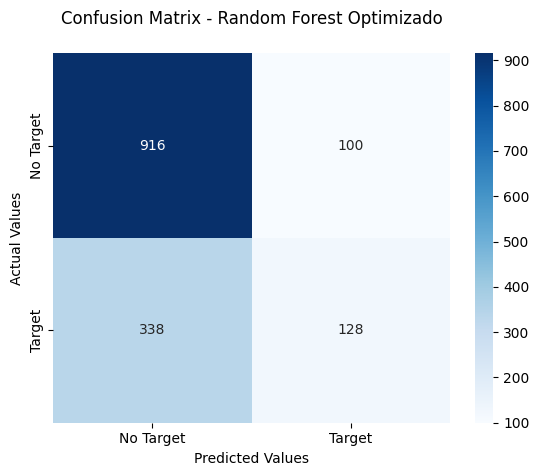

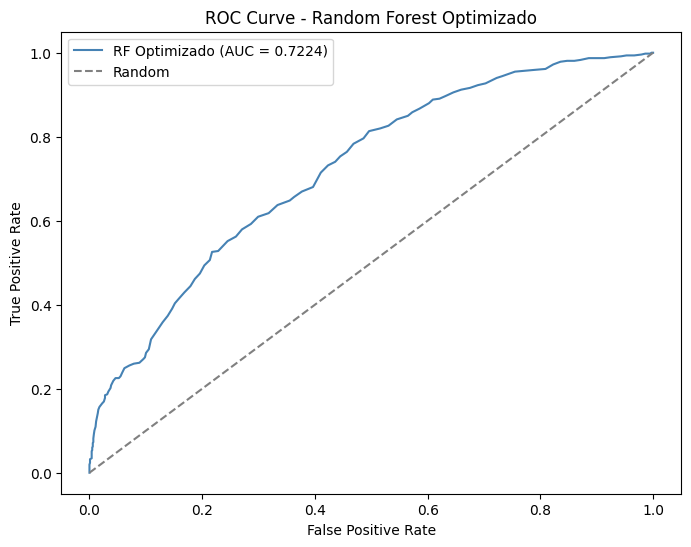

In [13]:
# Modelo final con los mejores hiperparámetros
rf_best = RandomForestClassifier(
    criterion         = 'entropy',
    max_depth         = None,
    max_features      = 7,
    min_samples_leaf  = 1,
    n_estimators      = 150,
    oob_score         = True,
    n_jobs            = -1,
    random_state      = 123
)

rf_best.fit(X_train, y_train)
print("OOB Score:", rf_best.oob_score_)

# Predicciones
pred_train = rf_best.predict(X_train)
pred_test  = rf_best.predict(X_test)
prob_test  = rf_best.predict_proba(X_test)[:, 1]

# Métricas
print(f"\nAccuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")

# Confusion Matrix
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Random Forest Optimizado\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'RF Optimizado (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Optimizado')
plt.legend()
plt.show()

El GridSearch no ha ayudado porque los mejores parámetros encontrados son max_depth=None y min_samples_leaf=1, exactamente los mismos que el modelo base. Esto significa que limitar la complejidad del árbol no mejora el modelo en este dataset.

El overfitting aquí no viene de árboles demasiado profundos sino del desbalance de clases luego el modelo aprende muy bien los no targets (mayoría) pero no generaliza bien en los targets. Por eso el siguiente paso, class_weight='balanced', debería ser el que realmente marque la diferencia.

### 4.23 Random Forest balanceado

class_weight='balanced' le dice al modelo que penalice más los errores en la clase minoritaria (targets) durante el entrenamiento.
En la práctica lo que hace es calcular automáticamente un peso para cada clase inversamente proporcional a su frecuencia:

Clase 0 (No Target): 3.316 filas → peso bajo
Clase 1 (Target): 1.525 filas → peso alto

La fórmula es: peso = total_filas / (n_clases × filas_de_esa_clase)
En tu caso:

Peso No Target = 4.841 / (2 × 3.316) = 0.73
Peso Target = 4.841 / (2 × 1.525) = 1.59

Esto significa que cuando el modelo comete un error clasificando un target como no target, ese error "pesa" el doble que el error contrario. Así el modelo aprende a prestar más atención a los targets aunque haya menos ejemplos de ellos.
El resultado esperado es que identifiques más targets correctamente (mejor recall) pero a costa de más falsos positivos. Es decir, clasificar algunas empresas como targets cuando no lo son.

OOB Score: 0.7168883747831116

Accuracy en train: 100.00%
Accuracy en test:  71.46%
AUC-ROC:           0.7204

Confusion Matrix -- TEST
[[915 101]
 [322 144]]


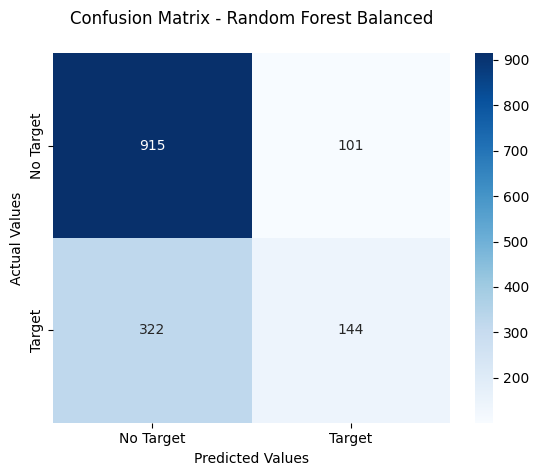

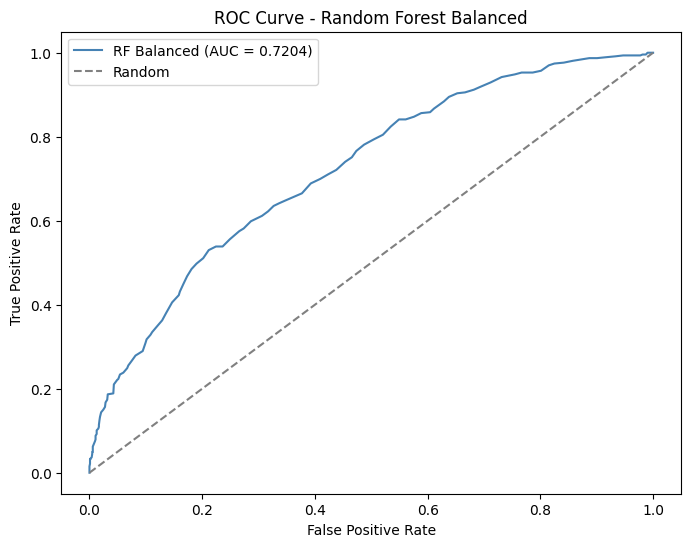

In [14]:
# Random Forest con class_weight='balanced'
rf_balanced = RandomForestClassifier(
    criterion         = 'entropy',
    max_depth         = None,
    max_features      = 7,
    min_samples_leaf  = 1,
    n_estimators      = 150,
    class_weight      = 'balanced',
    oob_score         = True,
    n_jobs            = -1,
    random_state      = 123
)

rf_balanced.fit(X_train, y_train)
print("OOB Score:", rf_balanced.oob_score_)

# Predicciones
pred_train = rf_balanced.predict(X_train)
pred_test  = rf_balanced.predict(X_test)
prob_test  = rf_balanced.predict_proba(X_test)[:, 1]

# Métricas
print(f"\nAccuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")

# Confusion Matrix
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Random Forest Balanced\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'RF Balanced (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Balanced')
plt.legend()
plt.show()

Los resultados mejoran ligeramente respecto al modelo base:

- AUC-ROC: 0.7204 (vs 0.7224 optimizado, vs 0.7136 base), prácticamente igual
- Accuracy test: 71.46%, similar
- **Targets identificados: 144 (vs 128 optimizado, vs 134 base)**, una pequeña mejora en recall 
- Falsos positivos: 101 (vs 100), prácticamente igual

El class_weight='balanced' ha ayudado marginalmente e identifica 16 targets más que el modelo optimizado pero el AUC-ROC es casi idéntico. El overfitting sigue presente (train 100%).

Los tres modelos de Random Forest hasta ahora son muy similares entre sí, lo que sugiere que el límite del Random Forest con estos datos está en torno a AUC 0.72. 

### 4.24 Regularización forzada en Random Forest

Opción 1 - Limitar max_depth: aunque el GridSearch eligió None, forzamos una profundidad máxima para simplificar los árboles

In [15]:
for depth in [3, 5, 10, 15, 20]:
    rf_test = RandomForestClassifier(
        criterion='entropy', max_depth=depth, max_features=7,
        min_samples_leaf=1, n_estimators=150,
        n_jobs=-1, random_state=123
    )
    rf_test.fit(X_train, y_train)
    pred_train = rf_test.predict(X_train)
    pred_test  = rf_test.predict(X_test)
    prob_test  = rf_test.predict_proba(X_test)[:, 1]
    print(f"max_depth={depth} | Train: {100*accuracy_score(y_train, pred_train):.1f}% | Test: {100*accuracy_score(y_test, pred_test):.1f}% | AUC: {roc_auc_score(y_test, prob_test):.4f}")

max_depth=3 | Train: 68.6% | Test: 68.6% | AUC: 0.6906
max_depth=5 | Train: 71.1% | Test: 69.6% | AUC: 0.7057
max_depth=10 | Train: 85.3% | Test: 71.1% | AUC: 0.7232
max_depth=15 | Train: 99.4% | Test: 71.3% | AUC: 0.7246
max_depth=20 | Train: 100.0% | Test: 71.2% | AUC: 0.7271


Bias-variance trade off:
Cuando simplificas el modelo (menos profundidad, más muestras en hoja) → reduces overfitting pero también baja el AUC
Cuando lo dejas complejo → mejor AUC pero train 100%

El punto de equilibrio está en max_depth=10:

Train: 85.3% vs Test: 71.1% es diferencia razonable, no perfecta pero ya no es 100%
AUC: 0.7232 que es prácticamente igual al modelo sin restricción (0.7224)

Vamos a probar con max_deth = 10

In [16]:
rf_final = RandomForestClassifier(
    criterion        = 'entropy',
    max_depth        = 10,
    max_features     = 7,
    min_samples_leaf = 1,
    n_estimators     = 150,
    oob_score        = True,
    n_jobs           = -1,
    random_state     = 123
)

rf_final.fit(X_train, y_train)

pred_train = rf_final.predict(X_train)
pred_test  = rf_final.predict(X_test)
prob_test  = rf_final.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 85.25%
Accuracy en test:  71.05%
AUC-ROC:           0.7232

Confusion Matrix -- TEST
[[947  69]
 [360 106]]


Opción 2 - Aumentar min_samples_leaf: exigir más observaciones en los nodos hoja simplifica el modelo

In [17]:
for leaf in [1, 5, 10, 20, 50]:
    rf_test = RandomForestClassifier(
        criterion='entropy', max_depth=None, max_features=7,
        min_samples_leaf=leaf, n_estimators=150,
        n_jobs=-1, random_state=123
    )
    rf_test.fit(X_train, y_train)
    pred_train = rf_test.predict(X_train)
    pred_test  = rf_test.predict(X_test)
    prob_test  = rf_test.predict_proba(X_test)[:, 1]
    print(f"min_samples_leaf={leaf} | Train: {100*accuracy_score(y_train, pred_train):.1f}% | Test: {100*accuracy_score(y_test, pred_test):.1f}% | AUC: {roc_auc_score(y_test, prob_test):.4f}")

min_samples_leaf=1 | Train: 100.0% | Test: 70.4% | AUC: 0.7224
min_samples_leaf=5 | Train: 95.3% | Test: 70.7% | AUC: 0.7242
min_samples_leaf=10 | Train: 87.7% | Test: 71.1% | AUC: 0.7203
min_samples_leaf=20 | Train: 80.5% | Test: 70.0% | AUC: 0.7120
min_samples_leaf=50 | Train: 74.7% | Test: 70.4% | AUC: 0.7059


Se exige un mínimo de 5 observaciones en cada nodo hoja para reducir la complejidad del modelo. Esto evita que los árboles creen ramas muy específicas basadas en pocos ejemplos, que es una de las causas principales del overfitting en Random Forest

In [18]:
rf_final = RandomForestClassifier(
    criterion        = 'entropy',
    max_depth        = None,
    max_features     = 7,
    min_samples_leaf = 5,
    n_estimators     = 150,
    oob_score        = True,
    n_jobs           = -1,
    random_state     = 123
)

rf_final.fit(X_train, y_train)

pred_train = rf_final.predict(X_train)
pred_test  = rf_final.predict(X_test)
prob_test  = rf_final.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 95.32%
Accuracy en test:  70.72%
AUC-ROC:           0.7242

Confusion Matrix -- TEST
[[926  90]
 [344 122]]


##### Probamos una combinación de ambos

Se combinan ambas restricciones simultáneamente para aplicar una regularización más agresiva. La combinación actúa desde dos ángulos, limitando tanto la profundidad global del árbol como la especificidad de sus nodos finales, buscando el mejor equilibrio posible entre bias y variance

In [19]:
rf_final = RandomForestClassifier(
    criterion        = 'entropy',
    max_depth        = 10,
    max_features     = 7,
    min_samples_leaf = 5,
    n_estimators     = 150,
    oob_score        = True,
    n_jobs           = -1,
    random_state     = 123
)

rf_final.fit(X_train, y_train)

pred_train = rf_final.predict(X_train)
pred_test  = rf_final.predict(X_test)
prob_test  = rf_final.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 80.51%
Accuracy en test:  70.85%
AUC-ROC:           0.7204

Confusion Matrix -- TEST
[[949  67]
 [365 101]]


### 4.25 Conclusión regularización Random Forest

Aquí tienes la comparativa de los tres:

| Modelo | Train | Test | AUC | Targets identificados | Diferencia train-test |
|--------|-------|------|-----|----------------------|----------------------|
| max_depth=10 | 85.25% | 71.05% | 0.7232 | 106 | 14.2 pts |
| min_samples_leaf=5 | 95.32% | 70.72% | 0.7242 | 122 | 24.6 pts |
| Combinación | 80.51% | 70.85% | 0.7204 | 101 | 9.7 pts |

**Conclusión:** ninguno es claramente superior en AUC (todos en torno a 0.72), pero se diferencian en dos aspectos:

- **Menor overfitting**: la combinación gana con solo 9.7 puntos de diferencia train-test
- **Más targets identificados**: min_samples_leaf=5 identifica 122 targets pero sigue con overfitting alto (24.6 pts)
- **Mejor equilibrio**: max_depth=10 es el punto medio con menos overfitting que min_samples_leaf y más targets que la combinación

Luego eligimos **`max_depth=10`** como el Random Forest base definitivo ya que es el mejor equilibrio entre overfitting controlado y capacidad de identificar targets

### 4.26 Random Forest + SMOTE

SMOTE (Synthetic Minority Oversampling Technique) es una técnica de sobremuestreo vista en clase que aborda el desbalance de clases desde un enfoque distinto al class_weight. En lugar de penalizar los errores en la clase minoritaria durante el entrenamiento, SMOTE genera ejemplos sintéticos de targets interpolando entre ejemplos reales existentes en el espacio de features. Concretamente, para cada target real selecciona sus k vecinos más cercanos y crea nuevos ejemplos a lo largo de las líneas que los conectan, aumentando así el número de targets en el conjunto de entrenamiento hasta alcanzar la proporción deseada.

SMOTE crea 'fake data' pero de forma inteligente, no aleatoria.
Por ejemplo, si tenemos dos empresas target reales con estas características:
Empresa A: market_cap=500, cash_ratio=0.3, leverage=0.2
Empresa B: market_cap=800, cash_ratio=0.5, leverage=0.1
SMOTE coge estas dos empresas, traza una línea entre ellas en el espacio de features, y crea una empresa sintética en algún punto de esa línea:
Empresa sintética: market_cap=650, cash_ratio=0.4, leverage=0.15

No es una empresa real, pero es "plausible" porque está entre dos empresas reales que sí fueron adquiridas. La idea es que si A y B son targets, una empresa con características a mitad de camino entre las dos también debería serlo.

La diferencia con imputación es que la imputación rellena valores que faltan en datos existentes, mientras que SMOTE crea filas enteras nuevas que no existían en el dataset original.

El riesgo, es overgeneralization. Si dos targets reales son muy distintos entre sí, la empresa sintética creada entre ellas puede no tener sentido financiero real.

La diferencia clave respecto a class_weight='balanced' es que SMOTE enriquece el dataset de entrenamiento con nueva información sintética, mientras que class_weight simplemente repondera los ejemplos existentes. En teoría esto debería ayudar al modelo a aprender mejor la frontera de decisión entre targets y no targets.

Se usa sampling_strategy=0.5, lo que significa que tras el resampleo habrá la mitad de targets que de no targets en train, un ratio 1:2 en lugar del original 1:2.2. Se mantiene el max_depth=10 del modelo optimizado anterior para controlar el overfitting. El test set nunca se toca con SMOTE, solo se aplica al train, ya que el test debe representar la realidad tal como es.

Before SMOTE, count label '1': 1086
Before SMOTE, count label '0': 2372

After SMOTE, shape X_train: (3558, 26)
After SMOTE, shape y_train: (3558,)
After SMOTE, count label '1': 1186
After SMOTE, count label '0': 2372

Accuracy en train: 86.73%
Accuracy en test:  71.39%
AUC-ROC:           0.7260

Confusion Matrix -- TEST
[[928  88]
 [336 130]]


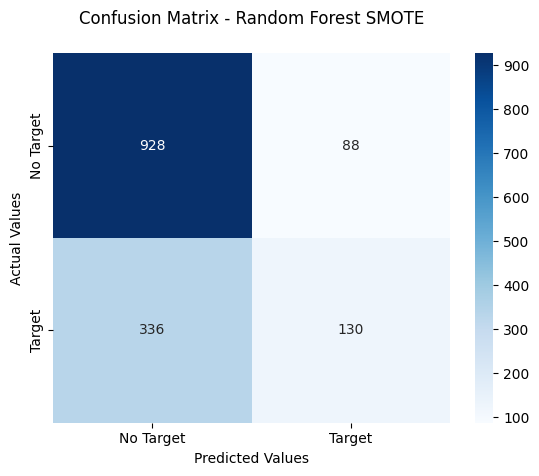

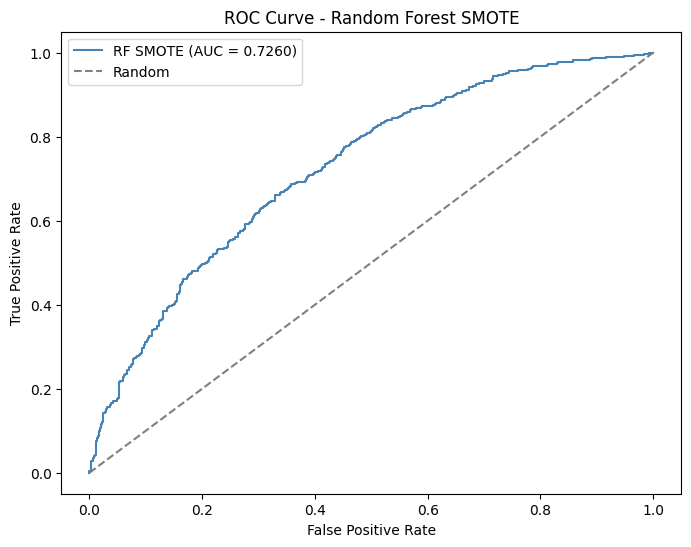

In [20]:
from imblearn.over_sampling import SMOTE

# Ver distribución antes
print("Before SMOTE, count label '1':", sum(y_train == 1))
print("Before SMOTE, count label '0':", sum(y_train == 0))

# Aplicar SMOTE solo al train (nunca al test)
sm = SMOTE(sampling_strategy=0.5, random_state=2, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train.ravel())

print('\nAfter SMOTE, shape X_train:', X_train_sm.shape)
print('After SMOTE, shape y_train:', y_train_sm.shape)
print("After SMOTE, count label '1':", sum(y_train_sm == 1))
print("After SMOTE, count label '0':", sum(y_train_sm == 0))

# Random Forest con los datos balanceados
rf_smote = RandomForestClassifier(
    criterion        = 'entropy',
    max_depth        = 10,
    max_features     = 7,
    min_samples_leaf = 1,
    n_estimators     = 150,
    oob_score        = False,   # OOB no funciona con SMOTE
    n_jobs           = -1,
    random_state     = 123
)

rf_smote.fit(X_train_sm, y_train_sm)

# Predicciones — siempre sobre el test original sin SMOTE
pred_train = rf_smote.predict(X_train_sm)
pred_test  = rf_smote.predict(X_test)
prob_test  = rf_smote.predict_proba(X_test)[:, 1]

print(f"\nAccuracy en train: {100*accuracy_score(y_train_sm, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")

print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Random Forest SMOTE\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'RF SMOTE (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest SMOTE')
plt.legend()
plt.show()

### 4.27 Comparación de los modelos Random Forest

Comparando los modelos:

| Modelo | Train | Test | AUC | Targets identificados | Overfitting |
|--------|-------|------|-----|----------------------|-------------|
| Base | 100% | 71.1% | 0.7136 | 134 | Severo |
| Optimizado (GridSearch) | 100% | 70.5% | 0.7224 | 128 | Severo |
| max_depth=10 | 85.3% | 71.1% | 0.7232 | 106 | Moderado |
| class_weight='balanced' | 100% | 71.5% | 0.7204 | 144 | Severo |
| **SMOTE** | **86.7%** | **71.4%** | **0.7260** | **130** | **Moderado** |

**SMOTE es el mejor modelo** ya que tiene el AUC más alto (0.7260), overfitting moderado (86.7% train vs 71.4% test) y 130 targets identificados. Además solo generó 100 ejemplos sintéticos (1.086 → 1.186 targets) lo que es conservador y reduce el riesgo de overgeneralization.

### 4.3 Gradient Boosting

Tras explorar Random Forest en sus distintas variantes, el AUC se ha estabilizado en torno a 0.72 sin mejoras significativas. Esto sugiere que el problema no es el overfitting sino la capacidad del modelo para capturar la señal que diferencia un target de un no target. A diferencia del Random Forest, que es un método de bagging que construye árboles independientes en paralelo para reducir la varianza, Gradient Boosting es un método de boosting que construye árboles de forma secuencial, donde cada árbol aprende específicamente de los errores del anterior. Esta capacidad de enfocarse iterativamente en los casos más difíciles de clasificar,  precisamente los targets que el modelo está fallando lo que lo convierte en un candidato más adecuado para este problema.

### 4.31 Primer modelo Gradient Boosting

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators  = 100,
    max_features  = 'sqrt',
    random_state  = 123
)

gb.fit(X_train, y_train)

# Predicciones
pred_train = gb.predict(X_train)
pred_test  = gb.predict(X_test)
prob_test  = gb.predict_proba(X_test)[:, 1]

# Métricas
print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 77.10%
Accuracy en test:  70.78%
AUC-ROC:           0.7083

Confusion Matrix -- TEST
[[943  73]
 [360 106]]


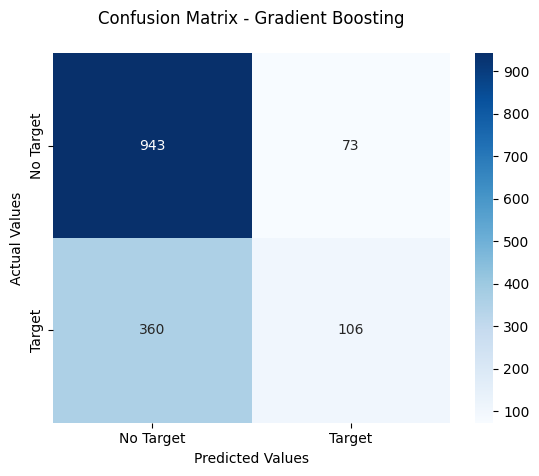

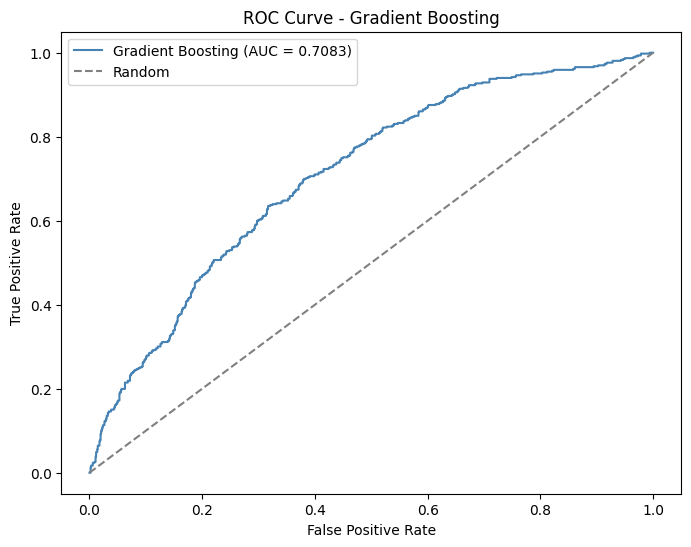

          predictor  importance
0             exchg    0.144473
22       market_cap    0.100010
23        ev_ebitda    0.066217
13             csho    0.054458
10             sale    0.051665
3               che    0.045487
25       cash_ratio    0.045395
1                ap    0.041374
24   asset_turnover    0.037940
7                dp    0.036710
18         leverage    0.035469
15             sich    0.034809
2                at    0.034070
14           prcc_f    0.031306
16       total_debt    0.027318
6              wcap    0.027265
9                ni    0.024552
5              rect    0.024199
19  capex_intensity    0.023422
21    current_ratio    0.021352
12             capx    0.019296
8            ebitda    0.018613
20              roa    0.016982
17    ebitda_margin    0.014254
11             xsga    0.012019
4                lt    0.011347


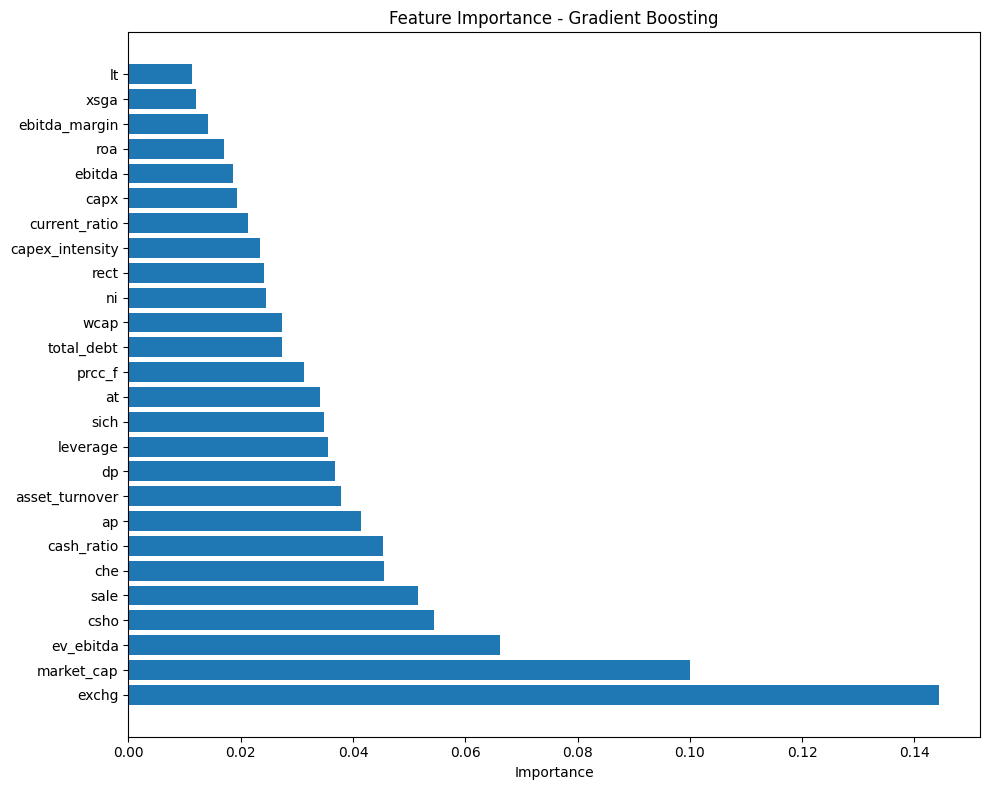

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Gradient Boosting\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'Gradient Boosting (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'predictor': feature_names,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance['predictor'], feature_importance['importance'])
ax.set_title('Feature Importance - Gradient Boosting')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

El Gradient Boosting base decepciona un poco:

AUC-ROC: 0.7083 — peor que Random Forest (0.7260 con SMOTE)
Accuracy test: 70.78% — similar
Targets identificados: 106 — menos que todos los Random Forest
Sin overfitting: train 77.1% vs test 70.8% — diferencia de solo 6 puntos

Lo más llamativo es el feature importance: exchg (bolsa donde cotiza) tiene una importancia desproporcionada de 0.14, casi el doble que market_cap. Esto es una señal de que el modelo está sobreponiendo peso en una variable que no causa directamente lo que quieres predecir, pero está correlacionada con otras variables que sí lo hacen. El modelo le le puede estar dando mucha importancia porque la bolsa donde cotiza está correlacionada con el tamaño y sector de la empresa. Las empresas grandes tienden a cotizar en NYSE, las tech en NASDAQ, etc. Entonces el modelo usa exchg como atajo para distinguir tipos de empresa en vez de aprender directamente de market_cap, sich u otras variables más directas. El problema es que esto no tiene sentido financiero real ya que una empresa no es más o menos probable de ser adquirida por cotizar en NYSE o NASDAQ, sino por sus características financieras.

Luego tenemos 2 opciones:
1. Eliminar exchg
2. Hacer el GridSearch con exchg incluida y ver si los hiperparámetros óptimos reducen su importancia

##### Opción 1 - Eliminar exchg

In [23]:
# Opción 1 — Sin exchg
feature_names_no_exchg = [f for f in feature_names if f != 'exchg']
X_train_no_exchg = X_train[:, [feature_names.index(f) for f in feature_names_no_exchg]]
X_test_no_exchg  = X_test[:,  [feature_names.index(f) for f in feature_names_no_exchg]]

gb_no_exchg = GradientBoostingClassifier(
    n_estimators = 100,
    max_features = 'sqrt',
    random_state = 123
)

gb_no_exchg.fit(X_train_no_exchg, y_train)

pred_train = gb_no_exchg.predict(X_train_no_exchg)
pred_test  = gb_no_exchg.predict(X_test_no_exchg)
prob_test  = gb_no_exchg.predict_proba(X_test_no_exchg)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 77.41%
Accuracy en test:  70.58%
AUC-ROC:           0.7007

Confusion Matrix -- TEST
[[948  68]
 [368  98]]


Eliminar exchg ha empeorado el modelo:

AUC-ROC: 0.7007 (vs 0.7083 con exchg) — peor
Targets identificados: 98 (vs 106 con exchg) — peor

Esto es contraintuitivo pero tiene una explicación — aunque exchg sea un proxy, está aportando información real al modelo. La bolsa donde cotiza sí discrimina entre tipos de empresa y esa información ayuda aunque no sea un predictor financiero "puro".

Conclusión: dejamos exchg en el modelo. Pasamos al GridSearch con todas las features incluyendo exchg.

##### Opción 2 - GridSearch con exchg

In [24]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators' : [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth'    : [3, 5, 7],
    'max_features' : ['sqrt']
}

gb_base = GradientBoostingClassifier(random_state=123)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid_search_gb = GridSearchCV(
    estimator  = gb_base,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

grid_search_gb.fit(X_train, y_train)

print("=" * 50)
print("Mejores hiperparámetros:")
print(grid_search_gb.best_params_)
print(f"Mejor AUC-ROC en CV: {grid_search_gb.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparámetros:
{'learning_rate': 0.01, 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 300}
Mejor AUC-ROC en CV: 0.7268


Mejora ligeramente Random Forest SMOTE, vamos entrenar el modelo con esos parámetros:

Accuracy en train: 87.80%
Accuracy en test:  71.46%
AUC-ROC:           0.7244

Confusion Matrix -- TEST
[[941  75]
 [348 118]]


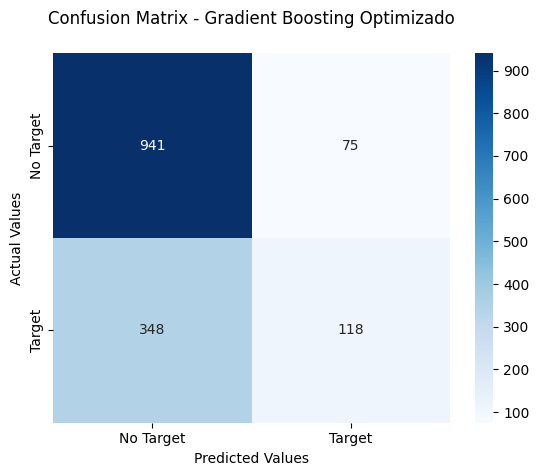

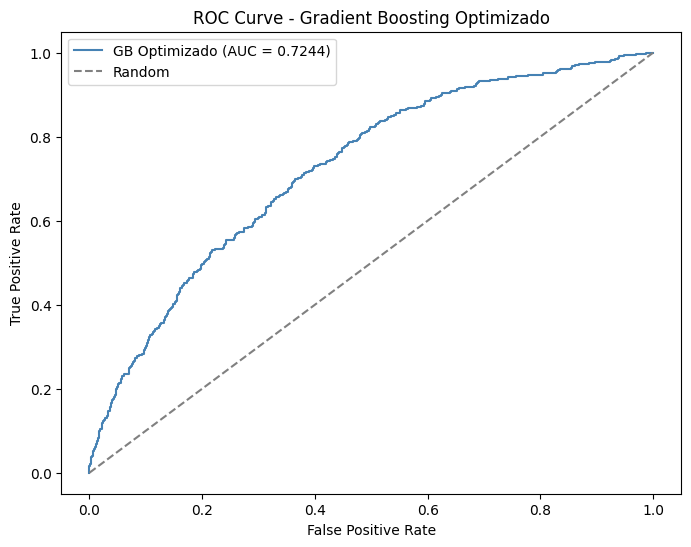

          predictor  importance
0             exchg    0.074802
22       market_cap    0.068990
23        ev_ebitda    0.056246
3               che    0.050730
24   asset_turnover    0.041420
25       cash_ratio    0.040166
13             csho    0.039997
10             sale    0.039915
1                ap    0.039454
2                at    0.037249
19  capex_intensity    0.036789
14           prcc_f    0.035840
7                dp    0.035285
15             sich    0.034141
4                lt    0.033698
17    ebitda_margin    0.032811
12             capx    0.032797
18         leverage    0.032639
8            ebitda    0.032165
11             xsga    0.031522
21    current_ratio    0.030844
6              wcap    0.029652
9                ni    0.028871
16       total_debt    0.028594
5              rect    0.028037
20              roa    0.027344


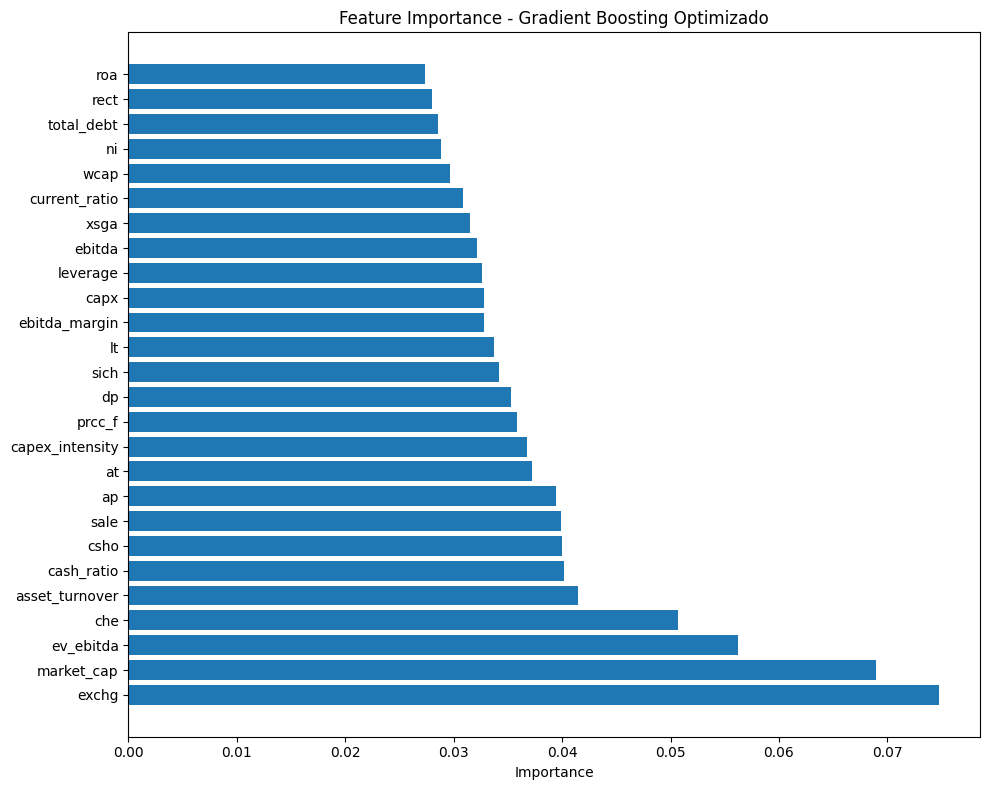

In [25]:
gb_best = GradientBoostingClassifier(
    learning_rate = 0.01,
    max_depth     = 7,
    max_features  = 'sqrt',
    n_estimators  = 300,
    random_state  = 123
)

gb_best.fit(X_train, y_train)

pred_train = gb_best.predict(X_train)
pred_test  = gb_best.predict(X_test)
prob_test  = gb_best.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

# Confusion Matrix visual
cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Gradient Boosting Optimizado\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'GB Optimizado (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting Optimizado')
plt.legend()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'predictor': feature_names,
    'importance': gb_best.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance['predictor'], feature_importance['importance'])
ax.set_title('Feature Importance - Gradient Boosting Optimizado')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

Resultados del Gradient Boosting optimizado:

- AUC-ROC: 0.7244 - ligeramente por debajo del RF SMOTE (0.7260)
- Accuracy test: 71.46% - similar a todos los modelos
- Targets identificados: 118 - razonable
- Overfitting moderado: train 87.8% vs test 71.5% - 16 puntos de diferencia

exchg sigue siendo la variable más importante (0.075) seguida de market_cap (0.069) y ev_ebitda (0.056). La distribución es mucho más equilibrada que en el modelo base y el learning rate bajo (0.01) con más árboles (300) ha repartido mejor la importancia entre variables.

Comparativa completa hasta ahora:

| Modelo | Train | Test | AUC | Targets |
|--------|-------|------|-----|---------|
| Logística | 68.4% | 68.3% | 0.5602 | 11 |
| RF max_depth=10 | 85.3% | 71.1% | 0.7232 | 106 |
| RF SMOTE | 86.7% | 71.4% | **0.7260** | 130 |
| GB base | 77.1% | 70.8% | 0.7083 | 106 |
| **GB Optimizado** | 87.8% | 71.5% | 0.7244 | **118** |

El RF SMOTE sigue siendo el mejor en AUC. Vamos a probar hacer boosting con SMOTE

### 4.32 Gradient Boosting + SMOTE

After SMOTE, count label '1': 1186
After SMOTE, count label '0': 2372

Accuracy en train: 89.54%
Accuracy en test:  71.79%
AUC-ROC:           0.7253

Confusion Matrix -- TEST
[[922  94]
 [324 142]]


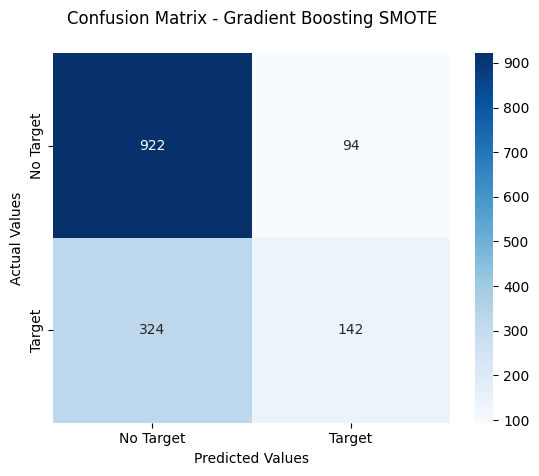

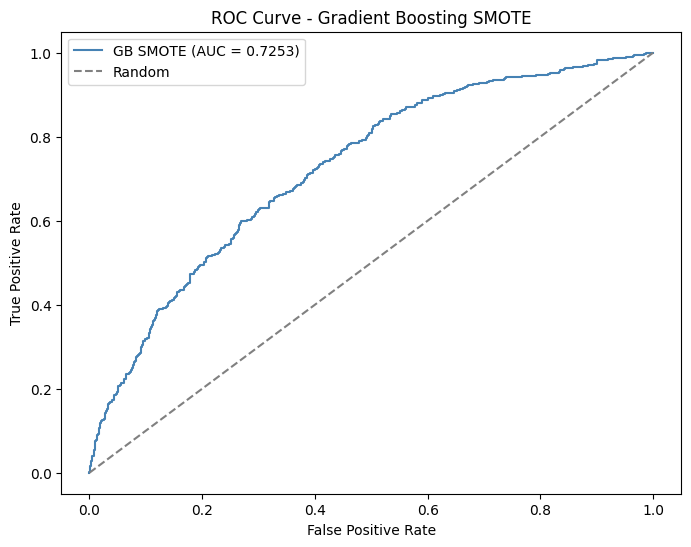

In [26]:
# Aplicar SMOTE al train para Gradient Boosting
sm = SMOTE(sampling_strategy=0.5, random_state=2, k_neighbors=5)
X_train_sm_gb, y_train_sm_gb = sm.fit_resample(X_train, y_train.ravel())

print("After SMOTE, count label '1':", sum(y_train_sm_gb == 1))
print("After SMOTE, count label '0':", sum(y_train_sm_gb == 0))

# Gradient Boosting con SMOTE y mejores hiperparámetros
gb_smote = GradientBoostingClassifier(
    learning_rate = 0.01,
    max_depth     = 7,
    max_features  = 'sqrt',
    n_estimators  = 300,
    random_state  = 123
)

gb_smote.fit(X_train_sm_gb, y_train_sm_gb)

pred_train = gb_smote.predict(X_train_sm_gb)
pred_test  = gb_smote.predict(X_test)
prob_test  = gb_smote.predict_proba(X_test)[:, 1]

print(f"\nAccuracy en train: {100*accuracy_score(y_train_sm_gb, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

# Confusion Matrix visual
cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - Gradient Boosting SMOTE\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'GB SMOTE (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting SMOTE')
plt.legend()
plt.show()

### 4.34 Conclusiones hasta ahora


| Modelo | Train | Test | AUC | Targets | Overfitting |
|--------|-------|------|-----|---------|-------------|
| Logística | 68.4% | 68.3% | 0.5602 | 11 | No |
| RF max_depth=10 | 85.3% | 71.1% | 0.7232 | 106 | Moderado |
| RF SMOTE | 86.7% | 71.4% | **0.7260** | 130 | Moderado |
| GB base | 77.1% | 70.8% | 0.7083 | 106 | Bajo |
| GB Optimizado | 87.8% | 71.5% | 0.7244 | 118 | Moderado |
| **GB SMOTE** | 89.5% | **71.8%** | 0.7253 | **142** | Moderado |

**GB SMOTE** tiene el mejor accuracy en test (71.8%) y más targets identificados (142), pero el **RF SMOTE** sigue teniendo el mejor AUC (0.7260).

La diferencia entre los dos mejores es mínima — 0.0007 de AUC. La elección depende de qué prioricemos:
- Si priorizamos **AUC** → RF SMOTE
- Si priorizamos **recall de targets** → GB SMOTE (142 vs 130)

Para M&A screening el recall de targets es más importante ya que mejor identificar más targets aunque alguno sea falso positivo que perder targets reales.

### 4.4 XGBoost

XGBoost es una implementación optimizada del algoritmo de Gradient Boosting desarrollada el cual su principal ventaja es que incorpora regularización L1 y L2 de forma nativa, algo que el Gradient Boosting estándar no tiene, lo que debería ayudar a controlar el overfitting que hemos observado en los modelos anteriores. Además es significativamente más rápido computacionalmente gracias a su implementación paralela, lo que permite explorar un espacio de hiperparámetros más amplio. Dado que el GB SMOTE ha sido el mejor modelo en términos de targets identificados (142) y el RF SMOTE en AUC (0.7260), se espera que XGBoost con su regularización incorporada pueda superar ambos resultados.

### 4.41 Modelo base XGBoost

Accuracy en train: 95.40%
Accuracy en test:  71.05%
AUC-ROC:           0.7162

Confusion Matrix -- TEST
[[894 122]
 [307 159]]


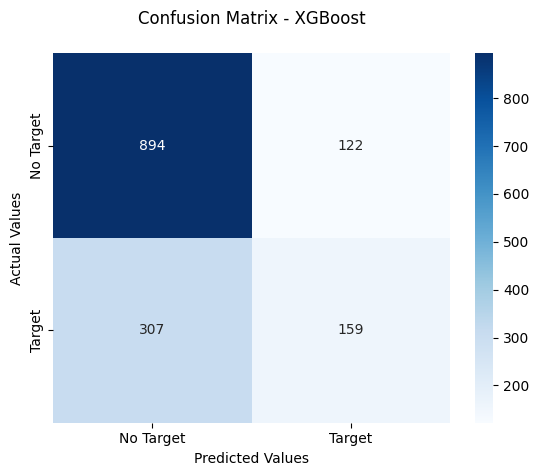

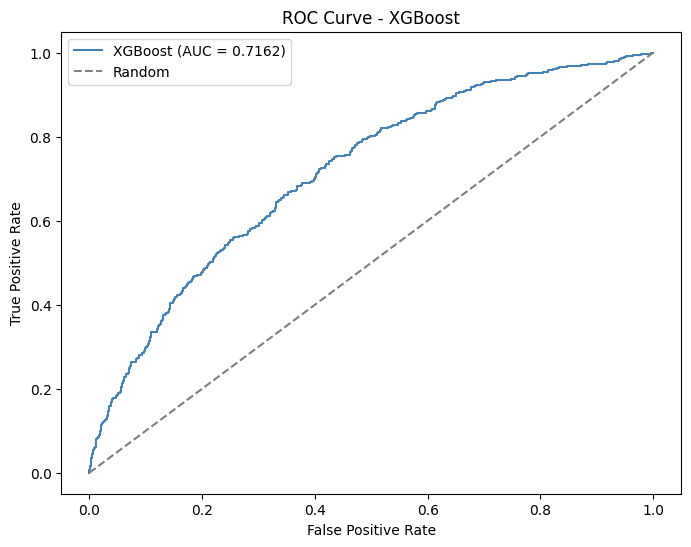

          predictor  importance
0             exchg    0.141575
22       market_cap    0.056735
3               che    0.043153
2                at    0.037367
10             sale    0.037220
23        ev_ebitda    0.036489
13             csho    0.035471
12             capx    0.034747
7                dp    0.034596
15             sich    0.033848
14           prcc_f    0.033682
24   asset_turnover    0.033325
4                lt    0.033034
17    ebitda_margin    0.032979
21    current_ratio    0.032887
16       total_debt    0.032295
1                ap    0.032209
8            ebitda    0.031943
5              rect    0.031699
19  capex_intensity    0.031461
20              roa    0.031114
25       cash_ratio    0.030993
11             xsga    0.030836
9                ni    0.030371
18         leverage    0.029987
6              wcap    0.029985


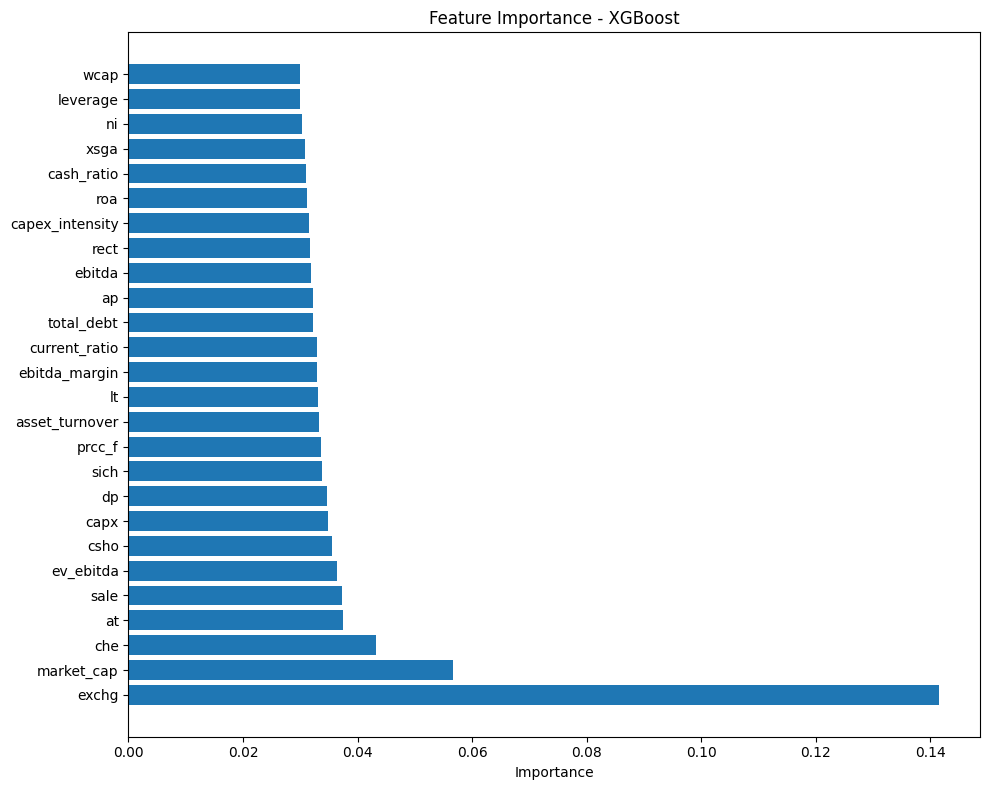

In [27]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators  = 100,
    max_depth     = 6,
    learning_rate = 0.1,
    subsample     = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder = False,
    eval_metric   = 'logloss',
    random_state  = 123,
    n_jobs        = -1
)

xgb.fit(X_train, y_train)

pred_train = xgb.predict(X_train)
pred_test  = xgb.predict(X_test)
prob_test  = xgb.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

# Confusion Matrix visual
cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - XGBoost\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'predictor': feature_names,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance['predictor'], feature_importance['importance'])
ax.set_title('Feature Importance - XGBoost')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

AUC-ROC: 0.7162 — por debajo del RF SMOTE y GB SMOTE
Accuracy test: 71.05% — similar a todos
Targets identificados: 159 — el mejor de todos los modelos hasta ahora
Overfitting moderado-alto: train 95.4% vs test 71.1%

El XGBoost base ya identifica más targets que cualquier otro modelo a pesar de tener un AUC menor. Esto tiene sentido porque XGBoost por defecto es más agresivo clasificando la clase minoritaria.

##### Volvemos a evaluar exchg

In [28]:
import pandas as pd

df_check = pd.read_csv('../data/processed/dataset_fase3_limpio.csv')

exchg_analysis = df_check.groupby(['exchg', 'ma_target']).size().unstack(fill_value=0)
exchg_analysis['total'] = exchg_analysis.sum(axis=1)
exchg_analysis['pct_target'] = (exchg_analysis[1] / exchg_analysis['total'] * 100).round(1)
print(exchg_analysis.sort_values('pct_target', ascending=False))

ma_target     0    1  total  pct_target
exchg                                  
15.0          0    1      1       100.0
17.0          2    3      5        60.0
14.0       1212  833   2045        40.7
11.0        913  489   1402        34.9
12.0        106   35    141        24.8
1.0          67   15     82        18.3
13.0         47    9     56        16.1
0.0         140   26    166        15.7
20.0          6    1      7        14.3
19.0        893  140   1033        13.6
2.0           1    0      1         0.0
18.0          1    0      1         0.0


exchg es un predictor genuino y muy informativo:

exchg=14 (NASDAQ): 40.7% de empresas adquiridas — con 2.045 empresas es el grupo más grande y más relevante
exchg=11 (NYSE): 34.9% de adquiridas — segundo grupo más grande
exchg=19 (OTC/Pink Sheets): solo 13.6% — empresas que cotizan fuera de las bolsas principales tienen mucha menos probabilidad de ser adquiridas
exchg=0: 15.7% — empresas sin bolsa clara, también baja probabilidad

Esto tiene sentido financiero real ya que las empresas que cotizan en NASDAQ y NYSE son las más líquidas, más seguidas por analistas y más atractivas para compradores estratégicos. Las empresas OTC son mucho menos atractivas para M&A.

Conclusión: exchg es un predictor financiero real y válido. El modelo lo usa correctamente. No hace falta ni eliminarlo ni convertirlo en dummies luego dejarlo como está y continuamos con el GridSearch de XGBoost

### 4.42 GridSearch CV en XGBoost

In [29]:
param_grid_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 123,
    n_jobs            = -1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid_search_xgb = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid_xgb,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

grid_search_xgb.fit(X_train, y_train)

print("=" * 50)
print("Mejores hiperparámetros:")
print(grid_search_xgb.best_params_)
print(f"Mejor AUC-ROC en CV: {grid_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores hiperparámetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Mejor AUC-ROC en CV: 0.7262


Aplicamos hiperparémtros al modelo

Accuracy en train: 97.74%
Accuracy en test:  70.58%
AUC-ROC:           0.7168

Confusion Matrix -- TEST
[[890 126]
 [310 156]]


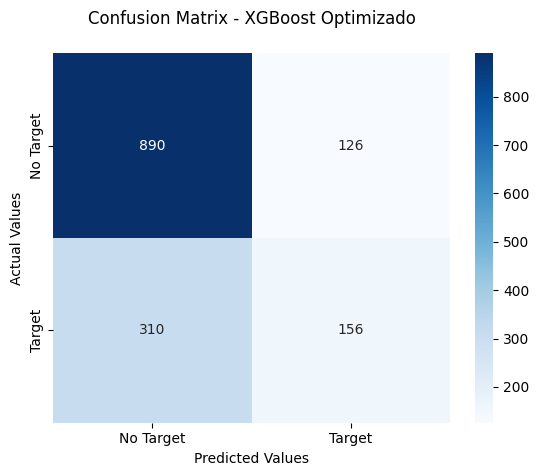

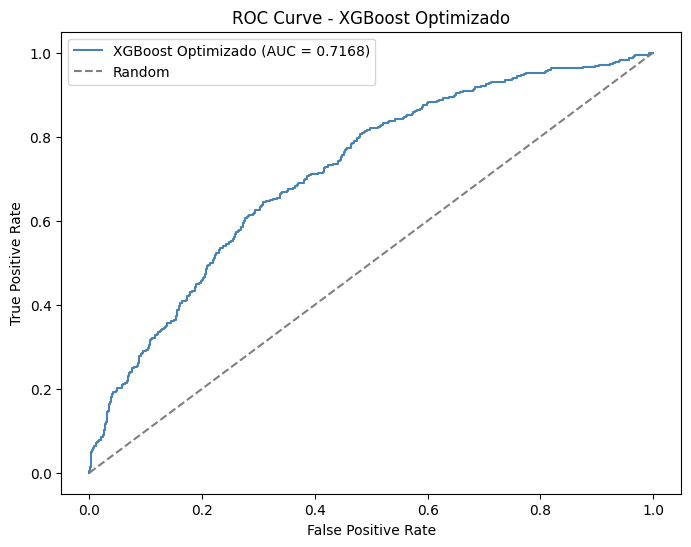

          predictor  importance
0             exchg    0.179468
22       market_cap    0.055072
23        ev_ebitda    0.038833
2                at    0.036838
24   asset_turnover    0.036392
16       total_debt    0.035975
12             capx    0.035252
3               che    0.034188
13             csho    0.033758
11             xsga    0.032717
14           prcc_f    0.032644
10             sale    0.031435
7                dp    0.030957
17    ebitda_margin    0.030838
19  capex_intensity    0.030644
4                lt    0.030593
25       cash_ratio    0.030251
15             sich    0.030248
1                ap    0.030113
18         leverage    0.029958
9                ni    0.029597
6              wcap    0.029319
8            ebitda    0.029139
21    current_ratio    0.029089
20              roa    0.028415
5              rect    0.028267


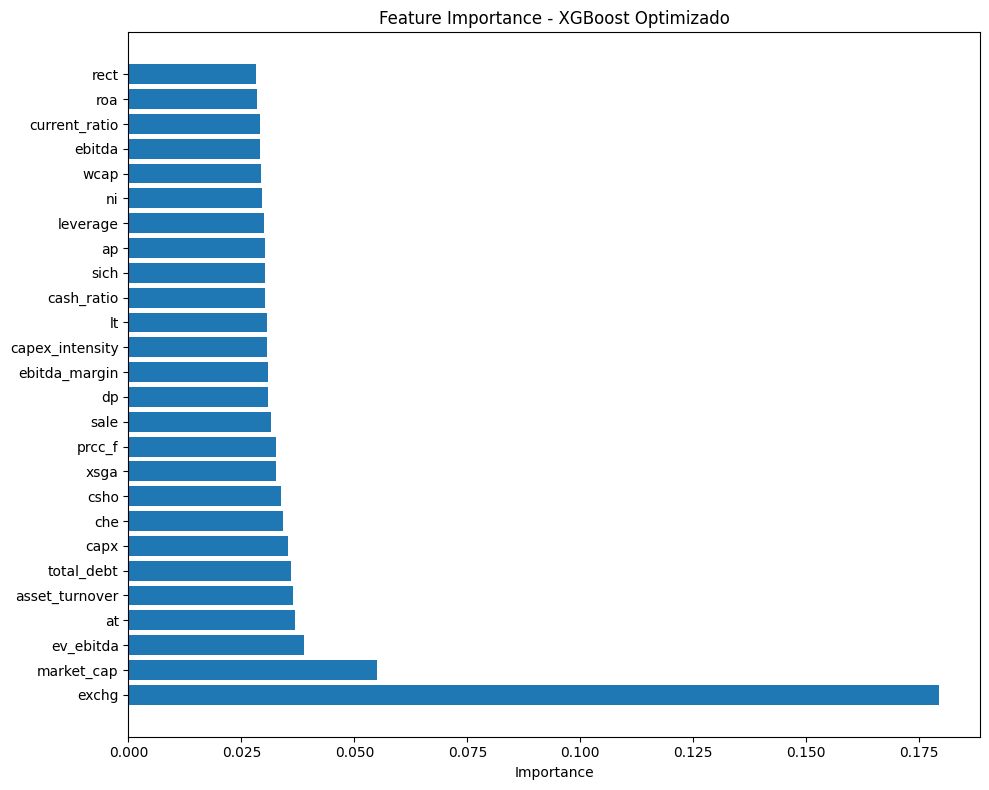

In [30]:
xgb_best = XGBClassifier(
    colsample_bytree  = 0.8,
    learning_rate     = 0.05,
    max_depth         = 7,
    n_estimators      = 200,
    subsample         = 1.0,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 123,
    n_jobs            = -1
)

xgb_best.fit(X_train, y_train)

pred_train = xgb_best.predict(X_train)
pred_test  = xgb_best.predict(X_test)
prob_test  = xgb_best.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

# Confusion Matrix visual
cm = confusion_matrix(y_test, pred_test)
ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - XGBoost Optimizado\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'XGBoost Optimizado (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Optimizado')
plt.legend()
plt.show()

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'predictor': feature_names,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_xgb.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance_xgb['predictor'], feature_importance_xgb['importance'])
ax.set_title('Feature Importance - XGBoost Optimizado')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

El GridSearch ha encontrado parámetros que aumentan el overfitting sin mejorar el AUC. Probamos con SMOTE para ver si mejora:

### 4.43 XGBoost + SMOTE

In [31]:
xgb_smote = XGBClassifier(
    colsample_bytree  = 0.8,
    learning_rate     = 0.05,
    max_depth         = 7,
    n_estimators      = 200,
    subsample         = 1.0,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 123,
    n_jobs            = -1
)

xgb_smote.fit(X_train_sm_gb, y_train_sm_gb)

pred_train = xgb_smote.predict(X_train_sm_gb)
pred_test  = xgb_smote.predict(X_test)
prob_test  = xgb_smote.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train_sm_gb, pred_train):.2f}%")
print(f"Accuracy en test:  {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC:           {roc_auc_score(y_test, prob_test):.4f}")
print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 98.12%
Accuracy en test:  70.24%
AUC-ROC:           0.7166

Confusion Matrix -- TEST
[[874 142]
 [299 167]]


##### Conclusiones de XGBoost

Interesante — SMOTE con XGBoost identifica **167 targets**, el máximo de todos los modelos, pero el AUC (0.7166) y el overfitting (98% train) siguen siendo problemáticos.

Aquí tienes la comparativa completa final:

| Modelo | Train | Test | AUC | Targets | Overfitting |
|--------|-------|------|-----|---------|-------------|
| Logística | 68.4% | 68.3% | 0.5602 | 11 | No |
| RF max_depth=10 | 85.3% | 71.1% | 0.7232 | 106 | Moderado |
| **RF SMOTE** | 86.7% | 71.4% | **0.7260** | 130 | Moderado |
| GB base | 77.1% | 70.8% | 0.7083 | 106 | Bajo |
| GB Optimizado | 87.8% | 71.5% | 0.7244 | 118 | Moderado |
| GB SMOTE | 89.5% | 71.8% | 0.7253 | 142 | Moderado |
| XGBoost base | 95.4% | 71.1% | 0.7162 | 159 | Alto |
| XGBoost Optimizado | 97.7% | 70.6% | 0.7168 | 156 | Alto |
| **XGBoost SMOTE** | 98.1% | 70.2% | 0.7166 | **167** | Alto |

**Conclusión:** hay un trade-off claro entre AUC y recall de targets. Para M&A screening el modelo ganador depende del objetivo:

- Si priorizamos **AUC y overfitting controlado** → **RF SMOTE**
- Si priorizamos **identificar el máximo de targets** → **XGBoost SMOTE**

### 4.5 LightGBM

#### 4.51 Modelo base

In [2]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.4 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
# Modelo base LightGBM
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=None,
    random_state=123,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

# Predicciones
pred_train = lgbm.predict(X_train)
pred_test = lgbm.predict(X_test)
prob_test = lgbm.predict_proba(X_test)[:, 1]

# Métricas
print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test: {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC: {roc_auc_score(y_test, prob_test):.4f}")

print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

[LightGBM] [Info] Number of positive: 1086, number of negative: 2372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6359
[LightGBM] [Info] Number of data points in the train set: 3458, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.314054 -> initscore=-0.781232
[LightGBM] [Info] Start training from score -0.781232
Accuracy en train: 97.48%
Accuracy en test: 70.78%
AUC-ROC: 0.7137

Confusion Matrix -- TEST
[[884 132]
 [301 165]]


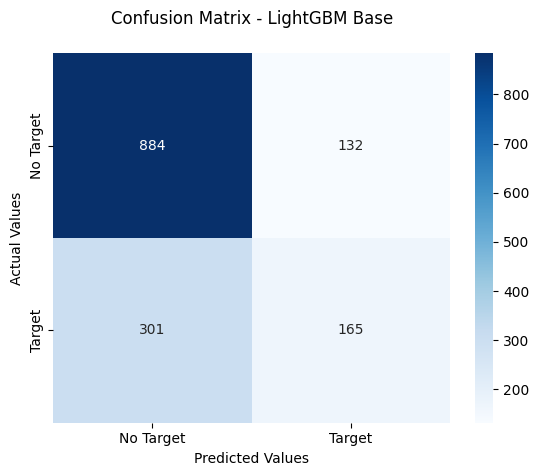

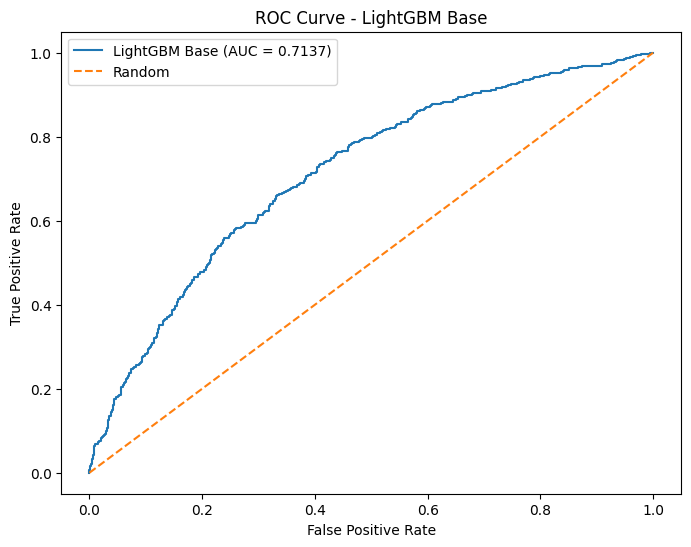

In [8]:
cm = confusion_matrix(y_test, pred_test)

ax = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix - LightGBM Base\n')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.xaxis.set_ticklabels(['No Target', 'Target'])
ax.yaxis.set_ticklabels(['No Target', 'Target'])
plt.show()

fpr, tpr, _ = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM Base (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM Base')
plt.legend()
plt.show()

 - El modelo base obtiene una **accuracy en train del 97,48 %** y una **accuracy en test del 70,78 %**.
  - El **AUC-ROC es 0,7137**, por lo que el modelo tiene cierta capacidad para distinguir entre targets y no targets, aunque no supera a las mejores versiones de Random Forest o Gradient Boosting.
  - La matriz de confusión muestra:
    - **884 verdaderos negativos**: empresas no target correctamente clasificadas.
    - **132 falsos positivos**: empresas no target clasificadas como target.
    - **301 falsos negativos**: targets reales no identificados.
    - **165 verdaderos positivos**: targets correctamente identificados.
  - El modelo identifica **165 de los 466 targets reales**, lo que supone un recall aproximado del **35,4 %**.
  - Sin embargo, la diferencia entre train y test es elevada, lo que indica **overfitting**. El modelo aprende muy bien el conjunto de entrenamiento, pero no generaliza con la misma fuerza sobre datos no vistos.


          predictor  importance
15             sich         169
19  capex_intensity         156
23        ev_ebitda         148
22       market_cap         146
17    ebitda_margin         144
9                ni         143
14           prcc_f         134
1                ap         134
13             csho         132
3               che         130
11             xsga         130
24   asset_turnover         127
20              roa         126
18         leverage         126
25       cash_ratio         122
7                dp         112
16       total_debt          99
21    current_ratio          93
5              rect          91
6              wcap          89
4                lt          84
2                at          83
12             capx          83
10             sale          82
8            ebitda          63
0             exchg          54


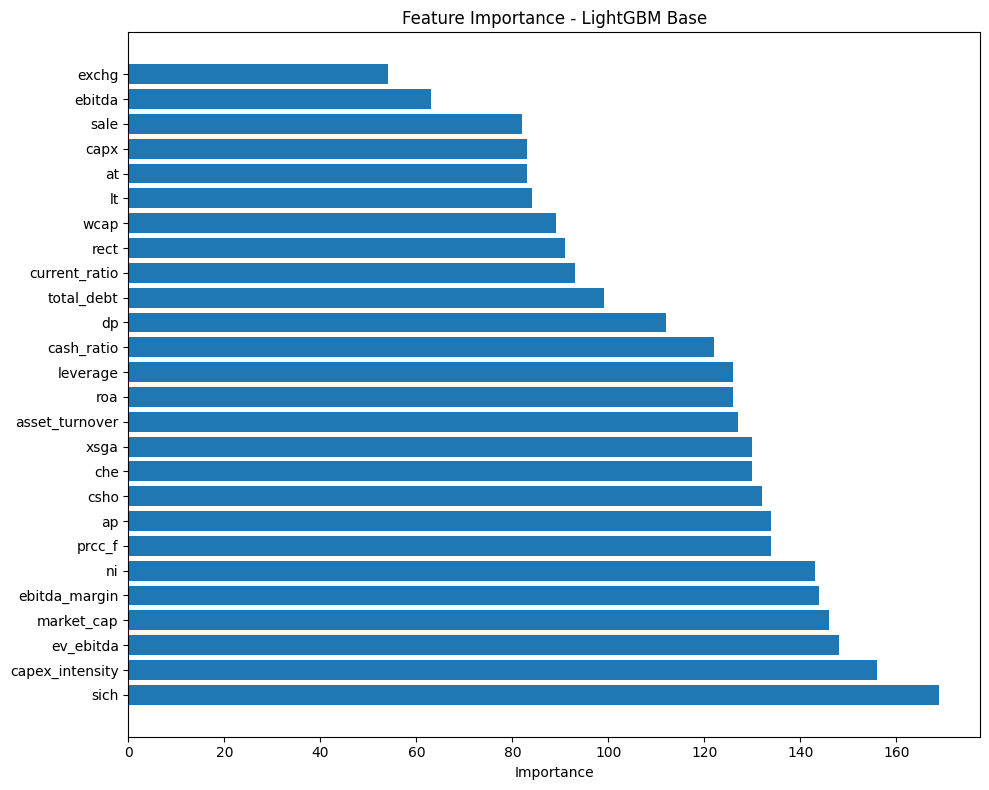

In [9]:
feature_importance_lgbm = pd.DataFrame({
    'predictor': feature_names,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_lgbm.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance_lgbm['predictor'], feature_importance_lgbm['importance'])
ax.set_title('Feature Importance - LightGBM Base')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

- La gráfica de feature importance del LightGBM base muestra que las variables con mayor peso son: sich, capex_intensity, ev_ebitda, market_cap, ebitda_margin, ni, prcc_f y ap
- Estas variables recogen información relacionada con sector, inversión, valoración, tamaño, rentabilidad, precio de mercado y estructura operativa.
- La presencia de sich como variable más importante debe interpretarse con cautela, ya que no es una variable financiera continua, sino un código sectorial.
- Esto sugiere que el sector de actividad tiene un papel relevante en la probabilidad estimada de adquisición, pero no debe interpretarse como una relación causal directa.
- La importancia de capex_intensity, ev_ebitda, market_cap y ebitda_margin es coherente con el contexto de M&A, ya que los compradores suelen analizar intensidad inversora, valoración, tamaño y rentabilidad de las compañías.


#### 4.52 LightGBM con GridSearch

In [11]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import warnings

warnings.filterwarnings("ignore")

lgbm_base = LGBMClassifier(
    random_state=123,
    n_jobs=-1,
    verbosity=-1,
    verbose=-1,
    force_col_wise=True
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid_search_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid_lgbm,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search_lgbm.fit(X_train, y_train)

print("=" * 50)
print("Mejores hiperparámetros:")
print(grid_search_lgbm.best_params_)
print(f"Mejor AUC-ROC en CV: {grid_search_lgbm.best_score_:.4f}")

Mejores hiperparámetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 15, 'subsample': 0.8}
Mejor AUC-ROC en CV: 0.7264


In [12]:
lgbm_best = LGBMClassifier(
    **grid_search_lgbm.best_params_,
    random_state=123,
    n_jobs=-1,
    verbosity=-1,
    verbose=-1,
    force_col_wise=True
)

lgbm_best.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
pred_train = lgbm_best.predict(X_train)
pred_test = lgbm_best.predict(X_test)
prob_test = lgbm_best.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test: {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC: {roc_auc_score(y_test, prob_test):.4f}")

print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 87.59%
Accuracy en test: 70.04%
AUC-ROC: 0.7194

Confusion Matrix -- TEST
[[900 116]
 [328 138]]


- El GridSearch selecciona los siguientes hiperparámetros:
    - `colsample_bytree = 0.8`
    - `learning_rate = 0.05`
    - `max_depth = -1`
    - `n_estimators = 200`
    - `num_leaves = 15`
    - `subsample = 0.8`
- El mejor AUC-ROC medio en validación cruzada es **0,7264**, lo que indica que durante la validación el modelo encuentra una configuración competitiva.
- Al evaluarlo sobre el conjunto de test, obtiene:
    - **Accuracy train:** 87,59 %
    - **Accuracy test:** 70,04 %
    - **AUC-ROC:** 0,7194
- La matriz de confusión muestra:
    - **900 verdaderos negativos**
    - **116 falsos positivos**
    - **328 falsos negativos**
    - **138 verdaderos positivos**
- El modelo optimizado reduce mucho el overfitting respecto al modelo base, ya que la accuracy de entrenamiento baja de 97,48 % a 87,59 %.
- Sin embargo, esta regularización también reduce el número de targets identificados, que pasa de **165 a 138**.
- Aunque el AUC mejora ligeramente respecto al modelo base, la mejora no es suficiente para superar al Random Forest con SMOTE.

#### 4.53 LightGBM con weight_class balanced

In [14]:
lgbm_balanced = LGBMClassifier(
    **grid_search_lgbm.best_params_,
    class_weight='balanced',
    random_state=123,
    n_jobs=-1
)

lgbm_balanced.fit(X_train, y_train)

pred_train = lgbm_balanced.predict(X_train)
pred_test = lgbm_balanced.predict(X_test)
prob_test = lgbm_balanced.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train, pred_train):.2f}%")
print(f"Accuracy en test: {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC: {roc_auc_score(y_test, prob_test):.4f}")

print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 85.89%
Accuracy en test: 66.73%
AUC-ROC: 0.7157

Confusion Matrix -- TEST
[[692 324]
 [169 297]]


- Esta versión se entrena dando más peso a la clase minoritaria, es decir, a las empresas target.
- El objetivo es que el modelo penalice más los errores cometidos sobre los targets y aumente su capacidad de detección.
- Los resultados son:
    - **Accuracy train:** 85,89 %
    - **Accuracy test:** 66,73 %
    - **AUC-ROC:** 0,7157
- Esta variante identifica **297 de los 466 targets reales**, lo que supone un recall aproximado del **63,7 %**.
- Es el modelo LightGBM que más targets detecta, pero lo hace a costa de aumentar mucho los falsos positivos.
- Los falsos positivos pasan de 116 en el modelo optimizado a 324 en el modelo balanceado.
- Esto implica que muchas empresas no target serían señaladas erróneamente como posibles targets.
- Para un screening muy amplio podría ser útil, porque reduce mucho los falsos negativos. Sin embargo, para una herramienta equilibrada genera demasiado ruido y reduce la fiabilidad del ranking.


#### 4.54 LightGBM con SMOTE

In [17]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE solo al train (nunca al test)
sm = SMOTE(sampling_strategy=0.5, random_state=2, k_neighbors=5)
X_train_sm_gb, y_train_sm_gb = sm.fit_resample(X_train, y_train.ravel())

lgbm_smote = LGBMClassifier(
    **grid_search_lgbm.best_params_,
    random_state=123,
    n_jobs=-1
)

lgbm_smote.fit(X_train_sm_gb, y_train_sm_gb)

pred_train = lgbm_smote.predict(X_train_sm_gb)
pred_test = lgbm_smote.predict(X_test)
prob_test = lgbm_smote.predict_proba(X_test)[:, 1]

print(f"Accuracy en train: {100*accuracy_score(y_train_sm_gb, pred_train):.2f}%")
print(f"Accuracy en test: {100*accuracy_score(y_test, pred_test):.2f}%")
print(f"AUC-ROC: {roc_auc_score(y_test, prob_test):.4f}")

print("\nConfusion Matrix -- TEST")
print(confusion_matrix(y_test, pred_test))

Accuracy en train: 87.55%
Accuracy en test: 70.72%
AUC-ROC: 0.7198

Confusion Matrix -- TEST
[[882 134]
 [300 166]]


- Esta versión se entrena dando más peso a la clase minoritaria, es decir, a las empresas target.
- El objetivo es que el modelo penalice más los errores cometidos sobre los targets y aumente su capacidad de detección.
- Los resultados son:
    - **Accuracy train:** 85,89 %
    - **Accuracy test:** 66,73 %
    - **AUC-ROC:** 0,7157
- Esta variante identifica **297 de los 466 targets reales**, lo que supone un recall aproximado del **63,7 %**.
- Es el modelo LightGBM que más targets detecta, pero lo hace a costa de aumentar mucho los falsos positivos.
- Los falsos positivos pasan de 116 en el modelo optimizado a 324 en el modelo balanceado.
- Esto implica que muchas empresas no target serían señaladas erróneamente como posibles targets.
- Para un screening muy amplio podría ser útil, porque reduce mucho los falsos negativos. Sin embargo, para una herramienta equilibrada genera demasiado ruido y reduce la fiabilidad del ranking.
- Por este motivo, aunque el recall mejora mucho, el modelo no se considera la mejor opción final.


#### 4.56 Comparación de modelos LightGBM

In [18]:
results_lgbm = pd.DataFrame({
    'Modelo': [
        'LightGBM Base',
        'LightGBM GridSearch',
        'LightGBM Balanced',
        'LightGBM SMOTE'
    ],
    'Accuracy Train': [
        accuracy_score(y_train, lgbm.predict(X_train)),
        accuracy_score(y_train, lgbm_best.predict(X_train)),
        accuracy_score(y_train, lgbm_balanced.predict(X_train)),
        accuracy_score(y_train_sm_gb, lgbm_smote.predict(X_train_sm_gb))
    ],
    'Accuracy Test': [
        accuracy_score(y_test, lgbm.predict(X_test)),
        accuracy_score(y_test, lgbm_best.predict(X_test)),
        accuracy_score(y_test, lgbm_balanced.predict(X_test)),
        accuracy_score(y_test, lgbm_smote.predict(X_test))
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, lgbm_best.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, lgbm_balanced.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, lgbm_smote.predict_proba(X_test)[:, 1])
    ],
    'Targets identificados': [
        confusion_matrix(y_test, lgbm.predict(X_test))[1, 1],
        confusion_matrix(y_test, lgbm_best.predict(X_test))[1, 1],
        confusion_matrix(y_test, lgbm_balanced.predict(X_test))[1, 1],
        confusion_matrix(y_test, lgbm_smote.predict(X_test))[1, 1]
    ]
})

results_lgbm

,Modelo,Accuracy Train,Accuracy Test,AUC-ROC,Targets identificados
0,LightGBM Base,0.974841,0.707827,0.713703,165
1,LightGBM GridSearch,0.875940,0.700405,0.719412,138
2,LightGBM Balanced,0.858878,0.667341,0.715733,297
3,LightGBM SMOTE,0.875492,0.707152,0.719822,166


In [19]:
def plot_confusion_matrix(model, X_test, y_test, model_name):
    """
    Plots the confusion matrix for a trained classification model.
    """
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        pd.DataFrame(cm),
        annot=True,
        cmap='Blues',
        fmt='g',
        cbar=False
    )
    
    ax.set_title(f'Confusion Matrix - {model_name}', fontsize=13)
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Actual Values')
    ax.xaxis.set_ticklabels(['No Target', 'Target'])
    ax.yaxis.set_ticklabels(['No Target', 'Target'])
    
    plt.tight_layout()
    plt.show()
    
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"Modelo: {model_name}")
    print(f"True Negatives: {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives: {tp}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print("-" * 50)

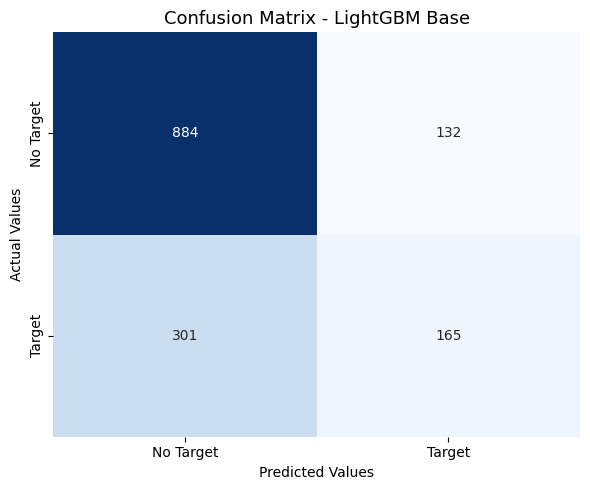

Modelo: LightGBM Base
True Negatives: 884
False Positives: 132
False Negatives: 301
True Positives: 165
Recall: 0.3541
Precision: 0.5556
--------------------------------------------------


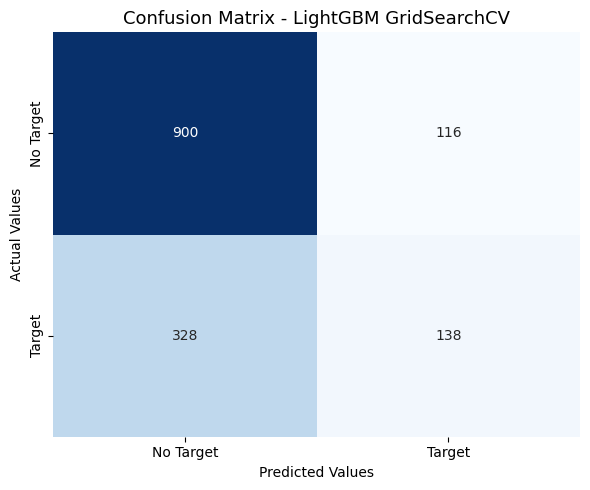

Modelo: LightGBM GridSearchCV
True Negatives: 900
False Positives: 116
False Negatives: 328
True Positives: 138
Recall: 0.2961
Precision: 0.5433
--------------------------------------------------


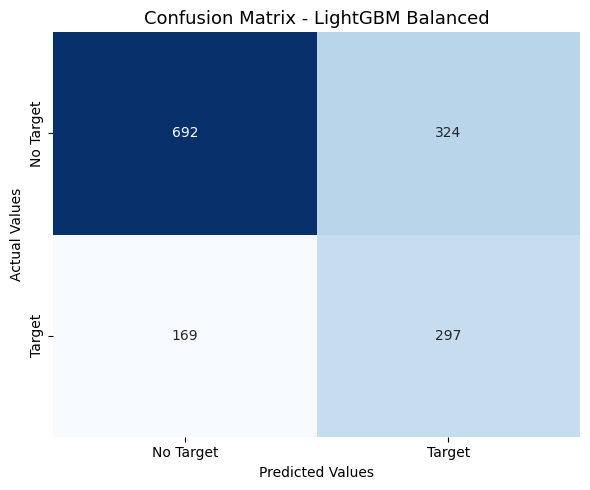

Modelo: LightGBM Balanced
True Negatives: 692
False Positives: 324
False Negatives: 169
True Positives: 297
Recall: 0.6373
Precision: 0.4783
--------------------------------------------------


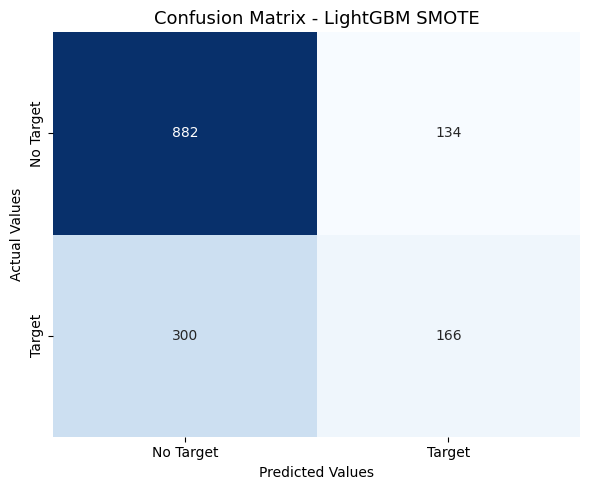

Modelo: LightGBM SMOTE
True Negatives: 882
False Positives: 134
False Negatives: 300
True Positives: 166
Recall: 0.3562
Precision: 0.5533
--------------------------------------------------


In [20]:
plot_confusion_matrix(lgbm, X_test, y_test, 'LightGBM Base')

plot_confusion_matrix(lgbm_best, X_test, y_test, 'LightGBM GridSearchCV')

plot_confusion_matrix(lgbm_balanced, X_test, y_test, 'LightGBM Balanced')

plot_confusion_matrix(lgbm_smote, X_test, y_test, 'LightGBM SMOTE')

In [21]:
def plot_roc_curve(model, X_test, y_test, model_name):
    """
    Plots the ROC curve for a trained classification model.
    """
    
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    print(f"AUC-ROC {model_name}: {auc:.4f}")
    print("-" * 50)

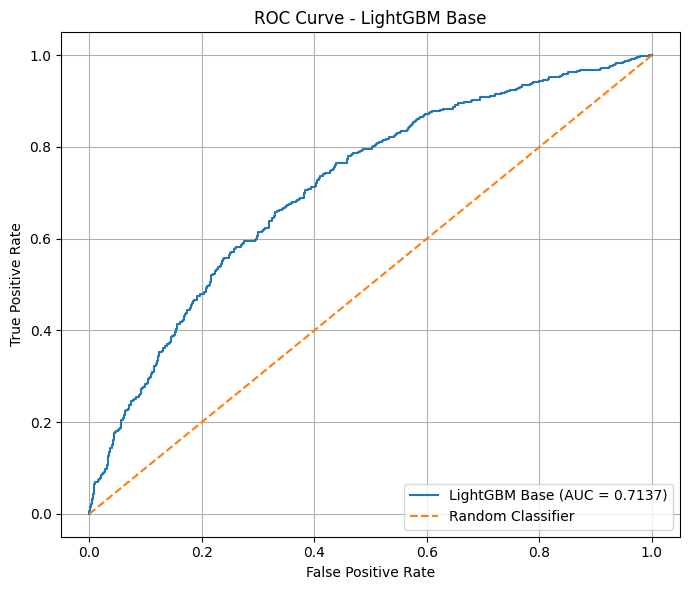

AUC-ROC LightGBM Base: 0.7137
--------------------------------------------------


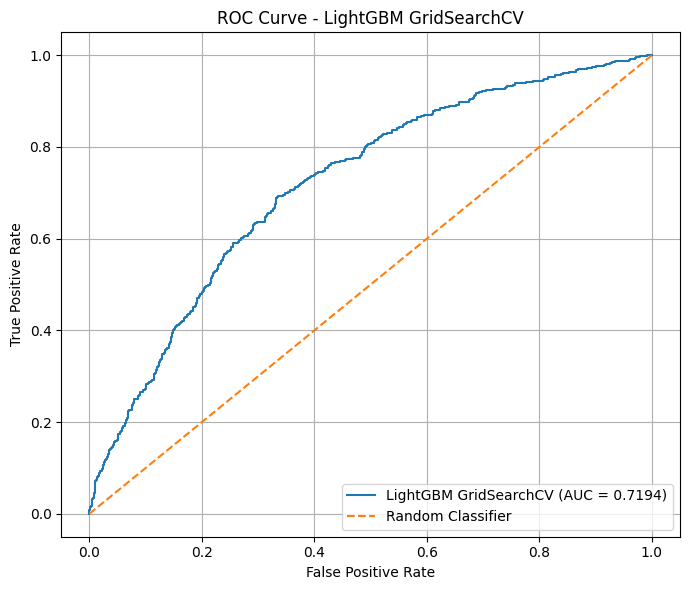

AUC-ROC LightGBM GridSearchCV: 0.7194
--------------------------------------------------


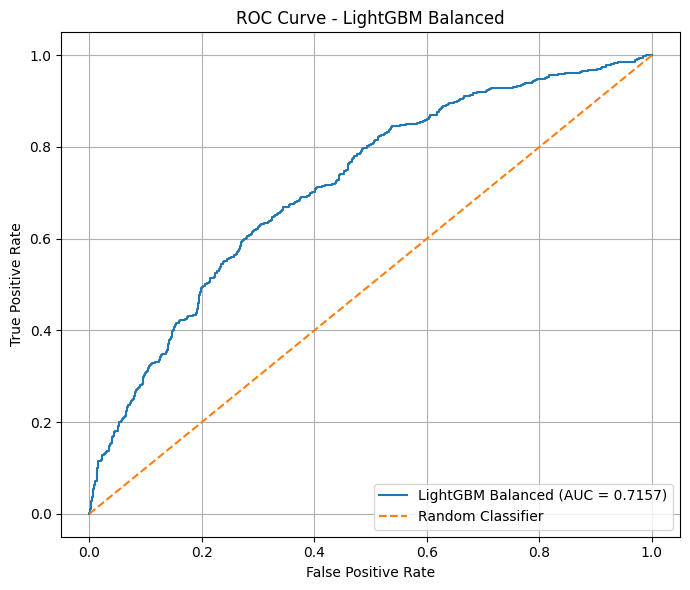

AUC-ROC LightGBM Balanced: 0.7157
--------------------------------------------------


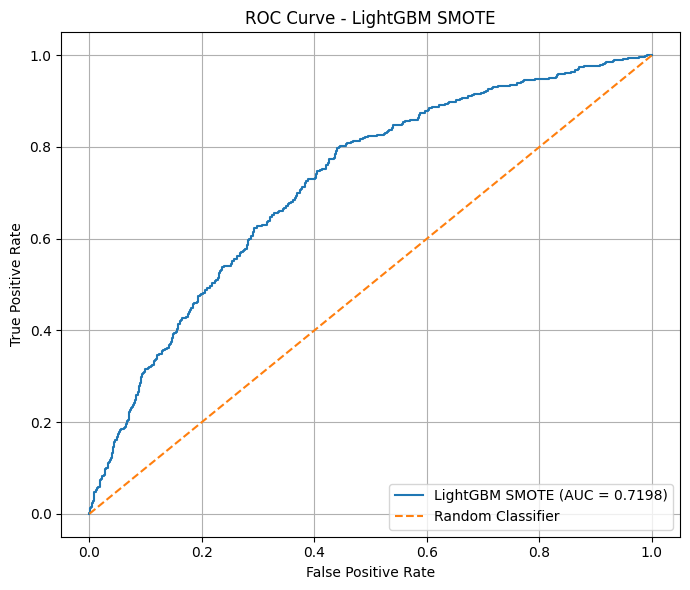

AUC-ROC LightGBM SMOTE: 0.7198
--------------------------------------------------


In [22]:
plot_roc_curve(lgbm, X_test, y_test, 'LightGBM Base')

plot_roc_curve(lgbm_best, X_test, y_test, 'LightGBM GridSearchCV')

plot_roc_curve(lgbm_balanced, X_test, y_test, 'LightGBM Balanced')

plot_roc_curve(lgbm_smote, X_test, y_test, 'LightGBM SMOTE')

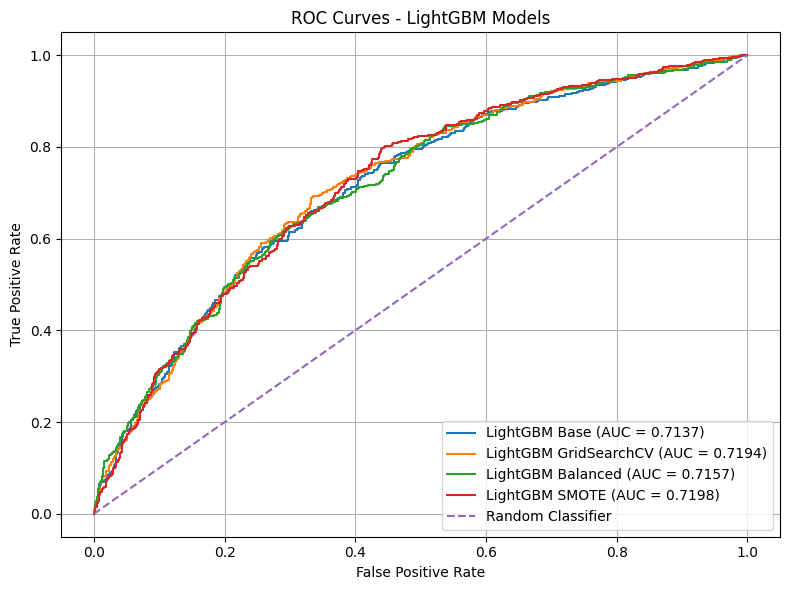

In [23]:
plt.figure(figsize=(8, 6))

models_lgbm = {
    'LightGBM Base': lgbm,
    'LightGBM GridSearchCV': lgbm_best,
    'LightGBM Balanced': lgbm_balanced,
    'LightGBM SMOTE': lgbm_smote
}

for model_name, model in models_lgbm.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - LightGBM Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.5 Elección del modelo final

Tras evaluar todos los modelos, se ha decidido seleccionar el Random Forest con SMOTE como modelo final del proyecto por las siguientes razones:

1. Desde un punto de vista técnico, es el modelo con mejor AUC-ROC (0.7260) y un overfitting moderado y controlado (86.7% en train frente a 71.4% en test), una diferencia de 15 puntos frente a los 28 puntos del XGBoost SMOTE. Como modelo adicional, se exploró LightGBM, algoritmo ampliamente utilizado en la literatura académica de clasificación financiera por su eficiencia computacional y buen rendimiento en datos tabulares. Sin embargo, ninguna de sus variantes superó al Random Forest con SMOTE en AUC-ROC, con el mejor resultado situándose en 0.7198 frente a 0.7260.

2. Desde un punto de vista de negocio, en M&A screening el coste de un falso negativo —no identificar una empresa que sí será adquirida— es mayor que el de un falso positivo. No obstante, la diferencia entre el RF SMOTE y el XGBoost SMOTE es de 37 targets sobre 466 reales, lo cual no justifica asumir 28 puntos adicionales de overfitting. En el caso del LightGBM, el mejor resultado obtenido (LightGBM SMOTE, 166 targets) tampoco supera al RF SMOTE ni en AUC ni en número de targets identificados, por lo que no ofrece ventaja competitiva que justifique el cambio de modelo.Finalmente, el Random Forest con SMOTE es el modelo más defendible académicamente: el Random Forest es un algoritmo bien establecido, SMOTE es una técnica de balanceo de clases vista en clase, y la distribución de feature importance es equilibrada entre variables, lo que facilita la interpretación económica de los resultados.

3. Finalmente, el Random Forest con SMOTE es el modelo más defendible académicamente: el Random Forest es un algoritmo bien establecido, SMOTE es una técnica de balanceo de clases vista en clase, y la distribución de feature importance es equilibrada entre variables, lo que facilita la interpretación económica de los resultados.

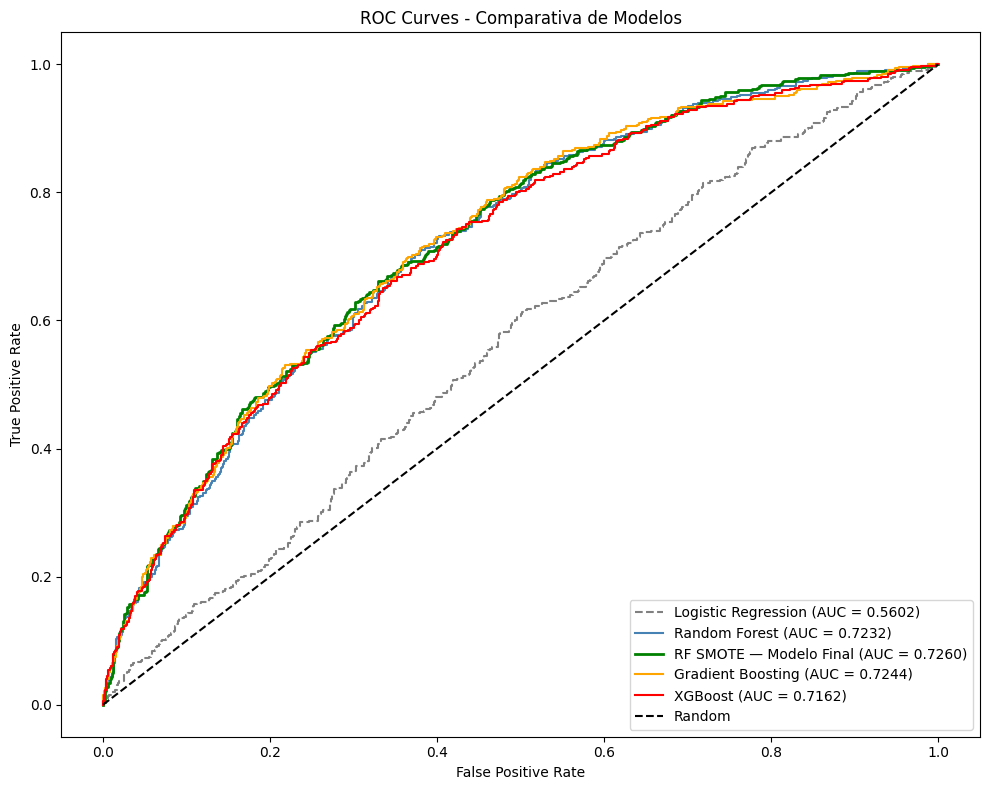

In [32]:
# Comparativa de ROC curves de los modelos principales
plt.figure(figsize=(10, 8))

# Logística
fpr_log, tpr_log, _ = roc_curve(y_test, predict_test)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = 0.5602)', linestyle='--', color='grey')

# RF max_depth=10
prob_rf = rf_final.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.7232)', color='steelblue')

# RF SMOTE — modelo final
prob_rf_smote = rf_smote.predict_proba(X_test)[:, 1]
fpr_rf_smote, tpr_rf_smote, _ = roc_curve(y_test, prob_rf_smote)
plt.plot(fpr_rf_smote, tpr_rf_smote, label=f'RF SMOTE — Modelo Final (AUC = 0.7260)', color='green', linewidth=2)

# GB Optimizado
prob_gb = gb_best.predict_proba(X_test)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = 0.7244)', color='orange')

# XGBoost base
prob_xgb = xgb.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = 0.7162)', color='red')

# Baseline aleatorio
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Comparativa de Modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 4.5 Guardamos el modelo final

##### Guardamos el modelo final aparte para poder llamarlo y utilizarlo en la siguiente fase: creación de dashboard e informes automatizados

In [33]:
import pickle, os

os.makedirs('../models', exist_ok=True)
with open('../models/mejor_modelo.pkl', 'wb') as f:
    pickle.dump(rf_smote, f)

print("Modelo guardado ✓")

Modelo guardado ✓
